# Laboratorio 7 — Spark ML Lib: salarios en la ENEIC

**CC3066 Data Science — Universidad del Valle de Guatemala — Semestre II 2026**

**Integrantes:** Dilary Cruz · Jose Ruiz · Gerardo Fernández

Preguntas que guían el análisis:

1. ¿Qué perfiles de trabajadores asalariados pueden identificarse según su edad, antigüedad y jornada habitual?
2. ¿Qué tan bien puede estimarse el salario mensual de una persona asalariada con características personales y laborales observadas?

**Datos:** bases de *Personas* de la Encuesta Nacional de Empleo e Ingresos Continua (ENEIC) del INE Guatemala.
Trimestres I–IV de 2025 → desarrollo/entrenamiento; trimestre I de 2026 → prueba final.
Fuente: https://www.ine.gob.gt/encuesta-nacional-de-empleo-e-ingresos/

> El notebook cubre los ejercicios **1–8**: preparación, exploración, clustering, dos pipelines de regresión, prueba final y análisis de errores.
> Las asociaciones encontradas no son causales ni recomendaciones sobre cuánto debería ganar una persona.
> Todos los resultados son **no ponderados**: describen los registros analizados, no a la población guatemalteca.

In [1]:
import math
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import openpyxl

from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, OneHotEncoder
from pyspark.ml.stat import Correlation
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator, RegressionEvaluator
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.sql.window import Window

# Módulo compartido del equipo (src/data_pipeline.py): armonización, filtros y diccionarios de códigos
sys.path.append(str(Path("../src").resolve()))
import data_pipeline as dp

spark = (SparkSession.builder
         .appName("Lab7-ENEIC")
         .master("local[4]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .config("spark.default.parallelism", "8")
         .config("spark.sql.execution.arrow.pyspark.enabled", "true")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

SEED = 42
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# Paleta categórica fija (se asigna en orden, nunca cíclica) y colores neutros
PALETA = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
TINTA, TINTA_2, GRILLA = "#1f1f1e", "#6b6a63", "#e4e3de"
MAPA_DIVERGENTE = LinearSegmentedColormap.from_list("azul_rojo", ["#2a78d6", "#f0efec", "#e34948"])
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": TINTA_2, "axes.labelcolor": TINTA, "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "axes.grid": True, "grid.color": GRILLA, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.titleweight": "bold", "axes.titlesize": 11, "font.size": 9.5,
})
print("Spark", spark.version)

/usr/local/lib/python3.11/site-packages/pyspark/bin/load-spark-env.sh: line 68: ps: command not found
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/26 03:10:27 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 3.5.1


### Configuración de archivos y códigos

Los archivos se descargaron del sitio del INE y se colocaron en `data/` (no se versionan; ver `.gitignore`).
Los códigos de las variables categóricas se tomaron de los diccionarios de datos (idénticos en los cinco trimestres):

In [2]:
DATA_DIR = Path("../data")
PARQUET_DIR = DATA_DIR / "parquet"
FORZAR_CONVERSION = False   # True para volver a leer los Excel aunque ya exista el Parquet crudo

ARCHIVOS = dp.ARCHIVOS                          # (periodo_archivo, anio, trimestre_calendario, archivo, uso)
REGISTROS_ESPERADOS = dp.REGISTROS_ESPERADOS    # conteos publicados en el enunciado
COLS_FUENTE = dp.COLS_FUENTE

# Diccionario de datos (P03A03A, P05C16, DOMINIO)
NIVEL_EDUCATIVO, CATEGORIA_OCUPACIONAL = dp.NIVEL_EDUCATIVO, dp.CATEGORIA_OCUPACIONAL
DOMINIO, DESCONOCIDO = dp.DOMINIO, dp.DESCONOCIDO

---
## 1. Carga, armonización y calidad de datos (5 pts)

### 1.1 Estructura de los archivos originales

Antes de leer los datos se inspecciona el encabezado de cada Excel: número de columnas y **posición** de las columnas requeridas.

In [3]:
def leer_encabezado(ruta):
    wb = openpyxl.load_workbook(ruta, read_only=True)
    ws = wb[wb.sheetnames[0]]
    encabezado = [str(c).strip() if c is not None else "" for c in next(ws.iter_rows(max_row=1, values_only=True))]
    wb.close()
    return encabezado

encabezados = {p: leer_encabezado(DATA_DIR / archivo) for p, _, _, archivo, _ in ARCHIVOS}

estructura = pd.DataFrame({p: {"n_columnas": len(h), **{c: h.index(c) + 1 for c in COLS_FUENTE}}
                           for p, h in encabezados.items()})
print("Número de columnas y posición (1-based) de las columnas requeridas en cada archivo:")
display(estructura)

faltantes_encabezado = {p: [c for c in COLS_FUENTE if c not in h] for p, h in encabezados.items()}
assert not any(faltantes_encabezado.values()), faltantes_encabezado

Número de columnas y posición (1-based) de las columnas requeridas en cada archivo:


,2025T1,2025T2,2025T3,2025T4,2026T1
n_columnas,270,270,270,302,270
ANIO,1,1,1,1,1
TRIMESTRE,2,2,2,2,2
DOMINIO,3,3,3,3,3
NUM_HOGAR,4,4,4,4,4
NUM_PERSONA,7,7,7,7,7
FACTOR,5,5,5,5,5
OCUPADOS,266,266,266,298,266
P02A03,13,13,13,9,13
P03A03A,33,33,33,29,33


### 1.2 Conversión Excel → Parquet

Spark no tiene lector nativo de Excel. Cada archivo se lee **individualmente** con pandas/openpyxl, conservando solo las 14 columnas requeridas
y leyéndolas como **texto** (`dtype=str`): un mismo código puede venir como número (`2`) o como texto (`'2'`), así que primero se preserva
el valor tal cual y después se tipifica en Spark de forma explícita. Cada archivo se guarda como Parquet crudo para no volver a leer el Excel.

In [4]:
def excel_a_parquet(periodo, archivo):
    destino = PARQUET_DIR / "crudo" / periodo
    existia = destino.exists() and not FORZAR_CONVERSION
    if FORZAR_CONVERSION and destino.exists():
        import shutil; shutil.rmtree(destino)
    dp.read_excel_columns(str(DATA_DIR / archivo), str(destino), spark)
    return "ya existía" if existia else "convertido"

for periodo, _, _, archivo, _ in ARCHIVOS:
    print(periodo, archivo, "->", excel_a_parquet(periodo, archivo))

2025T1 Personas_ENEIC_T1_2025.xlsx -> convertido
2025T2 Personas-ENEIC-T2-2025.xlsx -> convertido
2025T3 Base-de-datos-Personas-ENEIC-III-2025.xlsx -> convertido
2025T4 Base-de-datos-Personas-ENEIC-IV-2025.xlsx -> convertido
2026T1 Base-de-datos-Personas-ENEIC-I-2026.xlsx -> convertido


### 1.3 Armonización de tipos e identificación del período

* Texto vacío, `nan`, `None`, etc. se tratan como nulo.
* **Códigos** (`DOMINIO`, `OCUPADOS`, `P03A03A`, `P05C16`, …): se convierten a número y solo se aceptan si son enteros (`'2'`, `2`, `2.0` → `2`).
* **Variables numéricas** (edad, antigüedad, horas, salario, factor): se convierten a `double`.
* `periodo_archivo`, `anio_archivo` y `trimestre_calendario` se asignan **según el archivo de procedencia**, no a partir de `TRIMESTRE`
  (que se conserva sin modificar). También se conserva `archivo_origen`.
* Los cuatro archivos de 2025 se unen con **`unionByName`**.

In [5]:
def armonizar(periodo, anio, trimestre, archivo):
    return dp.harmonize(spark.read.parquet(str(PARQUET_DIR / "crudo" / periodo)), anio, trimestre, archivo)

armonizados = {p: armonizar(p, a, t, arch) for p, a, t, arch, _ in ARCHIVOS}

base_2025 = None
for p, _, _, _, uso in ARCHIVOS:
    if uso == "entrenamiento":
        base_2025 = armonizados[p] if base_2025 is None else base_2025.unionByName(armonizados[p])
base_2026 = armonizados["2026T1"]

base_2025 = base_2025.cache()
base_2026 = base_2026.cache()

base_2025.printSchema()
base_2025.show(5, truncate=False)

root
 |-- archivo_origen: string (nullable = false)
 |-- periodo_archivo: string (nullable = false)
 |-- anio_archivo: integer (nullable = false)
 |-- trimestre_calendario: integer (nullable = false)
 |-- ANIO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- NUM_HOGAR: string (nullable = true)
 |-- NUM_PERSONA: string (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- dominio_cod: integer (nullable = true)
 |-- ocupado: integer (nullable = true)
 |-- edad: double (nullable = true)
 |-- nivel_educativo_cod: integer (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- categoria_ocupacional_cod: integer (nullable = true)
 |-- salario_mensual: double (nullable = true)
 |-- horas_semanales: double (nullable = true)



+---------------------------+---------------+------------+--------------------+----+---------+---------+-----------+------+-----------+-------+----+-------------------+----------------+----------------+-------------------------+---------------+---------------+
|archivo_origen             |periodo_archivo|anio_archivo|trimestre_calendario|ANIO|TRIMESTRE|NUM_HOGAR|NUM_PERSONA|FACTOR|dominio_cod|ocupado|edad|nivel_educativo_cod|antiguedad_anios|antiguedad_meses|categoria_ocupacional_cod|salario_mensual|horas_semanales|
+---------------------------+---------------+------------+--------------------+----+---------+---------+-----------+------+-----------+-------+----+-------------------+----------------+----------------+-------------------------+---------------+---------------+
|Personas_ENEIC_T1_2025.xlsx|2025T1         |2025        |1                   |2025|2        |751      |1          |456.0 |3          |1      |46.0|0                  |25.0            |0.0             |7              

In [6]:
conteo_original = (base_2025.unionByName(base_2026)
                   .groupBy("periodo_archivo").count()
                   .toPandas().set_index("periodo_archivo").sort_index())
conteo_original["esperado"] = pd.Series(REGISTROS_ESPERADOS)
conteo_original["coincide"] = conteo_original["count"] == conteo_original["esperado"]
conteo_original = conteo_original.rename(columns={"count": "registros_originales"})
display(conteo_original)

print("Valores originales de TRIMESTRE por archivo (se conservan sin modificar):")
display(base_2025.unionByName(base_2026).groupBy("periodo_archivo", "TRIMESTRE").count()
        .orderBy("periodo_archivo", "TRIMESTRE").toPandas())

,registros_originales,esperado,coincide
periodo_archivo,,,
2025T1,51588,51588,True
2025T2,51167,51167,True
2025T3,51583,51583,True
2025T4,49338,49338,True
2026T1,49843,49843,True


Valores originales de TRIMESTRE por archivo (se conservan sin modificar):


,periodo_archivo,TRIMESTRE,count
0,2025T1,2,51588
1,2025T2,2,175
2,2025T2,3,50992
3,2025T3,4,51583
4,2025T4,5,49338
5,2026T1,6,49843


### 1.4 Faltantes antes de aplicar filtros

Se distinguen dos situaciones: **nulo** (celda vacía en el archivo) y **no convertible** (hay texto pero no es un número/código válido).
Se calculan sobre todos los registros de cada archivo, antes de filtrar.

In [7]:
MAPA_ANALITICO = {"ANIO": "ANIO", "TRIMESTRE": "TRIMESTRE", "DOMINIO": "dominio", "NUM_HOGAR": "NUM_HOGAR",
                  "NUM_PERSONA": "NUM_PERSONA", "FACTOR": "FACTOR", "OCUPADOS": "ocupado", "P02A03": "edad",
                  "P03A03A": "nivel_educativo", "P05C07A": "antiguedad_anios", "P05C07B": "antiguedad_meses",
                  "P05C16": "categoria_ocupacional", "P05D01": "salario_mensual", "P05H01A": "horas_semanales"}

def faltantes_crudos(periodo):
    filas = dp.missing_report(spark.read.parquet(str(PARQUET_DIR / "crudo" / periodo)))
    return pd.DataFrame([{"periodo_archivo": periodo, "nombre_analitico": MAPA_ANALITICO[f["variable_original"]], **f}
                         for f in filas])

faltantes = pd.concat([faltantes_crudos(p) for p, *_ in ARCHIVOS], ignore_index=True)
faltantes["pct_nulos"] = (100 * faltantes["nulos"] / faltantes["n"]).round(2)

tabla_faltantes_2025 = (faltantes[faltantes["periodo_archivo"].str.startswith("2025")]
                        .groupby(["variable_original", "nombre_analitico"], sort=False)[["n", "nulos", "no_convertibles"]].sum())
tabla_faltantes_2025["pct_nulos"] = (100 * tabla_faltantes_2025["nulos"] / tabla_faltantes_2025["n"]).round(2)
print("Faltantes en la unión de 2025 (antes de filtros):")
display(tabla_faltantes_2025)

print("Porcentaje de nulos por archivo:")
display(faltantes.pivot(index="variable_original", columns="periodo_archivo", values="pct_nulos").loc[COLS_FUENTE])

Faltantes en la unión de 2025 (antes de filtros):


,,n,nulos,no_convertibles,pct_nulos
variable_original,nombre_analitico,,,,
ANIO,ANIO,203676,0,0,0.00
TRIMESTRE,TRIMESTRE,203676,0,0,0.00
DOMINIO,dominio,203676,0,0,0.00
NUM_HOGAR,NUM_HOGAR,203676,0,0,0.00
NUM_PERSONA,NUM_PERSONA,203676,0,0,0.00
FACTOR,FACTOR,203676,0,0,0.00
OCUPADOS,ocupado,203676,115454,0,56.69
P02A03,edad,203676,0,0,0.00
P03A03A,nivel_educativo,203676,26344,0,12.93


Porcentaje de nulos por archivo:


periodo_archivo,2025T1,2025T2,2025T3,2025T4,2026T1
variable_original,,,,,
ANIO,0.00,0.00,0.00,0.00,0.00
TRIMESTRE,0.00,0.00,0.00,0.00,0.00
DOMINIO,0.00,0.00,0.00,0.00,0.00
NUM_HOGAR,0.00,0.00,0.00,0.00,0.00
NUM_PERSONA,0.00,0.00,0.00,0.00,0.00
FACTOR,0.00,0.00,0.00,0.00,0.00
OCUPADOS,56.83,56.33,56.63,56.96,56.40
P02A03,0.00,0.00,0.00,0.00,0.00
P03A03A,13.43,13.05,12.69,12.55,12.06


### 1.5 Unicidad de la clave `periodo_archivo + NUM_HOGAR + NUM_PERSONA`

Si una clave aparece más de una vez **dentro del mismo archivo**, se revisa si las filas son **repeticiones exactas**
(todas las columnas seleccionadas iguales) o **registros en conflicto** (misma clave, contenido distinto). No se usa `dropDuplicates()`.

In [8]:
CLAVE = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]
COLS_CONTENIDO = [c for c in base_2025.columns if c not in ("archivo_origen",)]

def revisar_unicidad(df, nombre):
    con_huella = df.withColumn("huella", F.sha2(F.to_json(F.struct(*COLS_CONTENIDO)), 256))
    claves_nulas = df.filter(F.col("NUM_HOGAR").isNull() | F.col("NUM_PERSONA").isNull()).count()
    grupos = (con_huella.groupBy(CLAVE)
              .agg(F.count(F.lit(1)).alias("n_filas"), F.countDistinct("huella").alias("n_versiones"))
              .filter("n_filas > 1").cache())
    resumen = grupos.agg(
        F.count(F.lit(1)).alias("claves_duplicadas"),
        F.coalesce(F.sum("n_filas"), F.lit(0)).alias("filas_involucradas"),
        F.coalesce(F.sum((F.col("n_versiones") == 1).cast("int")), F.lit(0)).alias("claves_repeticion_exacta"),
        F.coalesce(F.sum((F.col("n_versiones") > 1).cast("int")), F.lit(0)).alias("claves_en_conflicto"),
    ).first().asDict()
    print(f"{nombre}: {df.count():,} registros | claves con nulos: {claves_nulas} | "
          f"claves distintas: {df.select(CLAVE).distinct().count():,}")
    print("  ", resumen)
    return grupos

dups_2025 = revisar_unicidad(base_2025, "2025")
dups_2026 = revisar_unicidad(base_2026, "2026T1")

if dups_2025.count() > 0:
    print("Detalle de claves duplicadas en 2025 (primeras 10):")
    ejemplo = dups_2025.orderBy(F.desc("n_versiones")).limit(10)
    base_2025.join(ejemplo, CLAVE).orderBy(*CLAVE).show(30, truncate=False)

2025: 203,676 registros | claves con nulos: 0 | claves distintas: 203,676
   {'claves_duplicadas': 0, 'filas_involucradas': 0, 'claves_repeticion_exacta': 0, 'claves_en_conflicto': 0}
2026T1: 49,843 registros | claves con nulos: 0 | claves distintas: 49,843
   {'claves_duplicadas': 0, 'filas_involucradas': 0, 'claves_repeticion_exacta': 0, 'claves_en_conflicto': 0}


In [9]:
# Contexto longitudinal: la misma pareja NUM_HOGAR + NUM_PERSONA en varios trimestres
# (el identificador del hogar puede no ser estable entre trimestres; esto es solo exploratorio)
apariciones = (base_2025.groupBy("NUM_HOGAR", "NUM_PERSONA")
               .agg(F.countDistinct("periodo_archivo").alias("n_periodos"))
               .groupBy("n_periodos").count().orderBy("n_periodos"))
print("Número de trimestres de 2025 en que aparece cada combinación hogar-persona:")
apariciones.show()

Número de trimestres de 2025 en que aparece cada combinación hogar-persona:
+----------+-----+
|n_periodos|count|
+----------+-----+
|         1|31273|
|         2|27771|
|         3|16279|
|         4|17006|
+----------+-----+



### 1.6 Población analítica y filtros

Se aplican **siempre en el mismo orden** a 2025 y a 2026. Un registro se excluye en el **primer** paso que no cumple
(los valores que no permiten evaluar un criterio —nulos, NaN, infinitos— también se excluyen y se contabilizan en ese paso).
No se imputa el salario y no se recortan salarios extremos.

| Paso | Criterio |
|---|---|
| 1 | Edad finita y ≥ 15 |
| 2 | Ocupado (`OCUPADOS = 1`) |
| 3 | Asalariado (`P05C16` ∈ {1, 2, 3, 4}) |
| 4 | Salario (`P05D01`) numérico, finito y > 0 |
| 5 | Años de antigüedad finitos y ≥ 0 |
| 6 | Meses de antigüedad enteros entre 0 y 11 |
| 7 | Antigüedad = años + meses/12 ≤ edad |
| 8 | Horas habituales > 0 y ≤ 168 |

In [10]:
PASOS = dp.PASOS_NOMBRES
marcar_exclusion = dp.mark_exclusions

marcado_2025 = marcar_exclusion(base_2025)
marcado_2026 = marcar_exclusion(base_2026)

def tabla_exclusiones(marcado):
    conteos = marcado.groupBy("periodo_archivo", "motivo_exclusion").count().toPandas()
    pivote = conteos.pivot(index="motivo_exclusion", columns="periodo_archivo", values="count").fillna(0).astype(int)
    antes = pivote.sum()
    excluidos = pivote.reindex(PASOS).fillna(0).astype(int)
    filas = [("Registros originales", antes)]
    restantes = antes.copy()
    for paso in excluidos.index:
        filas.append((f"   excluidos en {paso}", -excluidos.loc[paso]))
        restantes = restantes - excluidos.loc[paso]
    filas.append(("Registros finales (población analítica)", restantes))
    tabla = pd.DataFrame({k: v for k, v in filas}).T
    tabla["Total"] = tabla.sum(axis=1)
    return tabla

tabla_filtros = pd.concat([tabla_exclusiones(marcado_2025).rename(columns={"Total": "Total 2025"}),
                           tabla_exclusiones(marcado_2026).drop(columns="Total")], axis=1)
print("Registros por archivo antes y después de cada filtro (valores negativos = excluidos en ese paso):")
display(tabla_filtros)

Registros por archivo antes y después de cada filtro (valores negativos = excluidos en ese paso):


periodo_archivo,2025T1,2025T2,2025T3,2025T4,Total 2025,2026T1
Registros originales,51588,51167,51583,49338,203676,49843
excluidos en 1. Edad finita y >= 15,-16253,-15882,-15767,-14984,-62886,-14803
excluidos en 2. Ocupado (OCUPADOS = 1),-13062,-12942,-13443,-13121,-52568,-13306
excluidos en 3. Asalariado (P05C16 en 1-4),-8854,-8851,-8923,-8569,-35197,-8476
excluidos en 4. Salario finito y > 0,0,0,0,0,0,0
excluidos en 5. Años de antigüedad >= 0,0,0,0,0,0,0
excluidos en 6. Meses enteros entre 0 y 11,0,0,0,0,0,0
excluidos en 7. Antigüedad <= edad,0,0,0,0,0,0
excluidos en 8. Horas > 0 y <= 168,0,0,0,0,0,0
Registros finales (población analítica),13419,13492,13450,12664,53025,13258


### 1.7 Variables categóricas, conjunto preparado y guardado en Parquet

Los códigos se validan contra el diccionario. Valores ausentes o no reconocidos se representan como **`DESCONOCIDO`**
(no como cero; el código educativo `0` significa *Ninguno*).

In [11]:
COLS_FINALES = dp.COLS_FINALES
preparar = dp.prepare_dataset

preparado_2025 = preparar(marcado_2025)
preparado_2026 = preparar(marcado_2026)

preparado_2025.write.mode("overwrite").parquet(str(PARQUET_DIR / "eneic_2025_preparado"))
preparado_2026.write.mode("overwrite").parquet(str(PARQUET_DIR / "eneic_2026T1_preparado"))

# A partir de aquí se trabaja con lo guardado en Parquet
df25 = spark.read.parquet(str(PARQUET_DIR / "eneic_2025_preparado")).cache()
df26 = spark.read.parquet(str(PARQUET_DIR / "eneic_2026T1_preparado")).cache()
print(f"Población analítica 2025: {df25.count():,} registros | 2026T1: {df26.count():,} registros")

for c in ["nivel_educativo", "categoria_ocupacional", "dominio"]:
    n_desc = df25.filter(F.col(c) == DESCONOCIDO).count()
    print(f"{c}: {n_desc} registros DESCONOCIDO en 2025")
df25.printSchema()

Población analítica 2025: 53,025 registros | 2026T1: 13,258 registros
nivel_educativo: 0 registros DESCONOCIDO en 2025
categoria_ocupacional: 0 registros DESCONOCIDO en 2025
dominio: 0 registros DESCONOCIDO en 2025
root
 |-- archivo_origen: string (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: integer (nullable = true)
 |-- trimestre_calendario: integer (nullable = true)
 |-- ANIO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- NUM_HOGAR: string (nullable = true)
 |-- NUM_PERSONA: string (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- ocupado: integer (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- antiguedad: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- salario_mensual: double (nullable = true)
 |-- nivel_educativo: string (nullable = true)
 |-- categoria_ocupacional: strin

### Hallazgos de calidad de datos

* **Conteos.** Los cinco archivos coinciden con los del enunciado (51,588 / 51,167 / 51,583 / 49,338 / 49,843). IV-2025 tiene 302 columnas y los demás 270.
* **`TRIMESTRE`.** Se conserva sin modificar: II-2025 trae 50,992 registros con valor 3 y 175 con valor 2, tal como advierte el enunciado. Por eso el trimestre calendario se toma del archivo.
* **Unicidad.** No hay claves `periodo_archivo + NUM_HOGAR + NUM_PERSONA` duplicadas ni nulas (203,676 claves distintas en 2025; 49,843 en 2026T1). Como no hay duplicados, no fue necesario separar repeticiones exactas de registros en conflicto ni usar `dropDuplicates()`.
* **Faltantes antes de filtrar.** `OCUPADOS`, `P05C07A`, `P05C07B`, `P05C16` y `P05H01A` tienen exactamente el mismo número de nulos (115,454; 56.69 %), el patrón de una pregunta que *no aplica*. `P05D01` (salario) tiene 150,651 nulos (73.97 %) y `P03A03A` (educación) 26,344 (12.93 %). No hubo valores no convertibles.
* **Exclusiones.** Los pasos 1 a 3 excluyen 62,886 registros (menores de 15 años, 30.9 %), 52,568 (no ocupados) y 35,197 (ocupados no asalariados); en conjunto son 150,651, el mismo número que los nulos de `P05D01`. Los pasos 4 a 8 (salario positivo, antigüedad, meses, antigüedad ≤ edad y horas) excluyen **0** registros: entre los asalariados ocupados de 15 años o más todos tienen salario positivo, antigüedad coherente y horas entre 1 y 126.
* **Población analítica.** 53,025 registros en 2025 (26.0 % de los 203,676) y 13,258 en 2026T1 (26.6 % de 49,843). Tras validar contra el diccionario no queda ningún `DESCONOCIDO` en las tres variables categóricas.
* **Rotación.** Contando la pareja `NUM_HOGAR + NUM_PERSONA` en 2025, 31,273 aparecen en un solo trimestre, 27,771 en dos, 16,279 en tres y 17,006 en los cuatro. Es consistente con el diseño con rotación, aunque esto es solo exploratorio: no se asume que el número de hogar sea un identificador estable entre trimestres.
* **Extremos.** El salario va de Q1 a Q99,000. No se elimina ni recorta ningún valor extremo, según las instrucciones; su influencia se discute en el ejercicio 2.

### 1.8 Preguntas

**¿Por qué IV de 2025 no puede apilarse por posición de columnas con los otros archivos?**
Porque tiene **302 columnas** en lugar de 270 y un orden distinto (tabla de la sección 1.1): por ejemplo, `P02A03` (edad) está en la posición 9
en IV-2025 y en la 13 en los demás; `P05D01` (salario) en la 98 frente a la 105; `OCUPADOS` en la 298 frente a la 266.
Una unión por posición (`union`) pegaría, por ejemplo, datos de otra pregunta debajo de la edad o del salario sin generar ningún error,
porque Spark solo verifica que el número de columnas y los tipos sean compatibles. `unionByName` alinea las columnas por su nombre,
que es lo que identifica a la variable en el diccionario.

**¿Qué diferencia existe entre un dato ausente porque la pregunta no corresponde y una respuesta no registrada?**
El primero es un **faltante estructural** (*no aplica*): el flujo del cuestionario salta la pregunta. Por ejemplo, a quien no está ocupado no se le
pregunta el salario, la antigüedad ni la categoría ocupacional; por eso esas variables tienen porcentajes altos de nulos en la tabla de 1.4.
No es un problema de calidad y no debe imputarse: la pregunta no tiene respuesta para esa persona.
La **respuesta no registrada** ocurre cuando la pregunta *sí* aplicaba (p. ej. un asalariado ocupado) pero no hay valor: no sabe, no quiso
responder o hubo un error de captura. Ese faltante sí es pérdida de información y puede sesgar resultados si no es aleatorio
(p. ej. si las personas de salarios altos responden menos). En estos datos, los 150,651 nulos de `P05D01` coinciden en número con los
registros excluidos por los pasos 1 a 3 (menores de 15 años, no ocupados y no asalariados): son faltantes estructurales. Entre los asalariados
ocupados de 15 años o más no se encontró ningún salario faltante ni no positivo (los pasos 4 a 8 excluyeron 0 registros), es decir,
no hay evidencia de no respuesta en la variable objetivo dentro de la población analítica.

**¿Por qué una persona observada en dos períodos no debe eliminarse como duplicado del conjunto longitudinal?**
La ENEIC tiene un diseño con rotación: parte de los hogares se entrevista en trimestres consecutivos. Cada fila es una
**observación persona-período**, no una persona. Si la misma persona aparece en T1 y T2, sus respuestas pueden cambiar (salario, horas, empleo)
y cada registro pertenece a la muestra (y al factor de expansión) de su propio trimestre. Eliminarla dejaría a un trimestre sin parte de su
muestra y alteraría su composición. Por eso la unicidad se verifica con la clave **`periodo_archivo + NUM_HOGAR + NUM_PERSONA`**: solo se esperan
claves únicas *dentro* de un mismo archivo. Esto también implica que el número de filas acumulado no es el número de personas distintas.

**¿Por qué el número de registros de la base filtrada no representa a todos los trabajadores del país?**
1. Es una **muestra**: cada registro representa a muchas personas según `FACTOR`, y el análisis es no ponderado.
2. La población se restringió a **asalariados** (gobierno, empresa privada, jornaleros, servicio doméstico) con **salario positivo registrado**:
   quedan fuera trabajadores por cuenta propia, patronos, trabajadores no remunerados y asalariados sin salario reportado.
3. Se excluyeron registros con datos incompletos o inconsistentes (antigüedad, horas).
4. Al unir cuatro trimestres, una misma persona puede contarse varias veces.

**Uso de `FACTOR`.** Es el factor de expansión: el número de personas de la población que representa cada registro según el diseño muestral.
En un análisis poblacional se usaría como peso: totales (`sum(FACTOR)`), medias y proporciones ponderadas y, con la información del diseño
(estratos y conglomerados), errores estándar. Al unir trimestres habría que dividir el factor entre el número de trimestres para obtener
un promedio anual. En este laboratorio se conserva, pero no se usa en el clustering, los modelos ni las métricas.

---
## 2. Estadística descriptiva y exploración (5 pts)

Todas las estadísticas se calculan con Spark sobre **todos** los registros de la población analítica de 2025.
Los percentiles son exactos (`percentile`), no aproximados.

In [12]:
NUMERICAS = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]

def resumen_numerico(df, cols):
    aggs = []
    for c in cols:
        aggs += [F.count(c).alias(f"{c}|n"), F.mean(c).alias(f"{c}|media"), F.stddev(c).alias(f"{c}|desv_est"),
                 F.min(c).alias(f"{c}|min"), F.max(c).alias(f"{c}|max"),
                 F.expr(f"percentile({c}, array(0.25, 0.5, 0.75, 0.95))").alias(f"{c}|pct"),
                 F.skewness(c).alias(f"{c}|asimetria")]
    fila = df.agg(*aggs).first().asDict()
    filas = []
    for c in cols:
        p25, p50, p75, p95 = fila[f"{c}|pct"]
        filas.append({"variable": c, "n": fila[f"{c}|n"], "media": fila[f"{c}|media"], "mediana": p50,
                      "desv_est": fila[f"{c}|desv_est"], "min": fila[f"{c}|min"], "p25": p25, "p75": p75,
                      "p95": p95, "max": fila[f"{c}|max"], "asimetria": fila[f"{c}|asimetria"]})
    return pd.DataFrame(filas).set_index("variable")

desc_2025 = resumen_numerico(df25, NUMERICAS)
display(desc_2025.round(2))

,n,media,mediana,desv_est,min,p25,p75,p95,max,asimetria
variable,,,,,,,,,,
salario_mensual,53025,3421.68,3000.0,2902.11,1.0,1800.0,4000.0,8000.0,99000.0,6.00
edad,53025,35.19,33.0,13.52,15.0,24.0,44.0,61.0,89.0,0.74
antiguedad,53025,5.56,2.0,7.83,0.0,0.5,7.0,22.0,70.0,2.40
horas_semanales,53025,46.31,45.0,18.63,1.0,40.0,55.0,80.0,126.0,0.59


### 2.1 Distribución de registros entre categorías ocupacionales, niveles educativos y dominios

categoria_ocupacional


,n,pct
categoria_ocupacional,,
1 - Empleado de gobierno,6575,12.40
2 - Empleado empresa privada,28702,54.13
3 - Jornalero o peón,13842,26.10
4 - Servicio doméstico,3906,7.37


nivel_educativo


,n,pct
nivel_educativo,,
0 - Ninguno,3995,7.53
1 - Preprimaria,459,0.87
2 - Primaria,15822,29.84
3 - Básico,8249,15.56
4 - Diversificado,16851,31.78
5 - Superior,6818,12.86
6 - Maestría,771,1.45
7 - Doctorado,60,0.11


dominio


,n,pct
dominio,,
1 - Urbano Metropolitano,22072,41.63
2 - Resto Urbano,20146,37.99
3 - Rural Nacional,10807,20.38


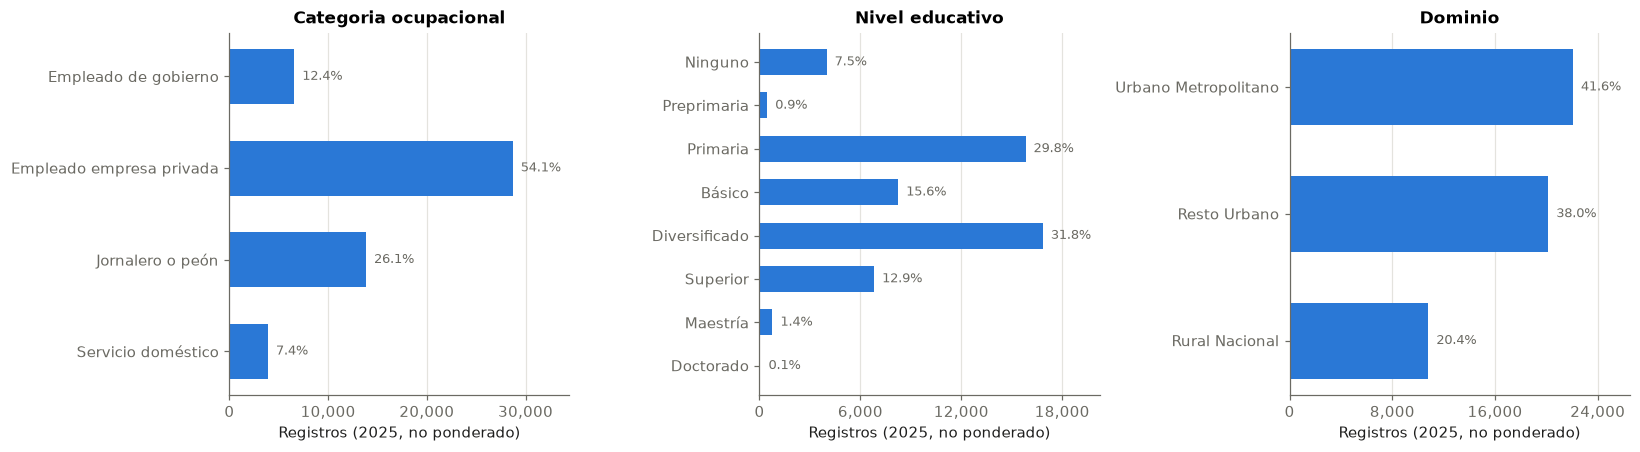

In [13]:
def conteo_categoria(df, col):
    t = df.groupBy(col).count().toPandas().sort_values(col).set_index(col)["count"]
    return pd.DataFrame({"n": t, "pct": (100 * t / t.sum()).round(2)})

conteos_cat = {c: conteo_categoria(df25, c) for c in ["categoria_ocupacional", "nivel_educativo", "dominio"]}
for c, t in conteos_cat.items():
    print(c); display(t)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (c, t) in zip(axes, conteos_cat.items()):
    etiquetas = [s.split(" - ", 1)[-1] for s in t.index]
    ax.barh(etiquetas, t["n"], color=PALETA[0], height=0.6)
    for y, (n, p) in enumerate(zip(t["n"], t["pct"])):
        ax.text(n, y, f"  {p:.1f}%", va="center", color=TINTA_2, fontsize=8.5)
    ax.invert_yaxis()
    ax.set_title(c.replace("_", " ").capitalize())
    ax.set_xlabel("Registros (2025, no ponderado)")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.set_xlim(0, t["n"].max() * 1.2)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(4))
    ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

### 2.2 Distribución del salario: simetría, media y mediana

Media: Q3,421.68 | Mediana: Q3,000.00 | Diferencia: Q421.68 (14.1% sobre la mediana)
Asimetría (skewness): 6.00 | P95: Q8,000.00 | Máximo: Q99,000.00


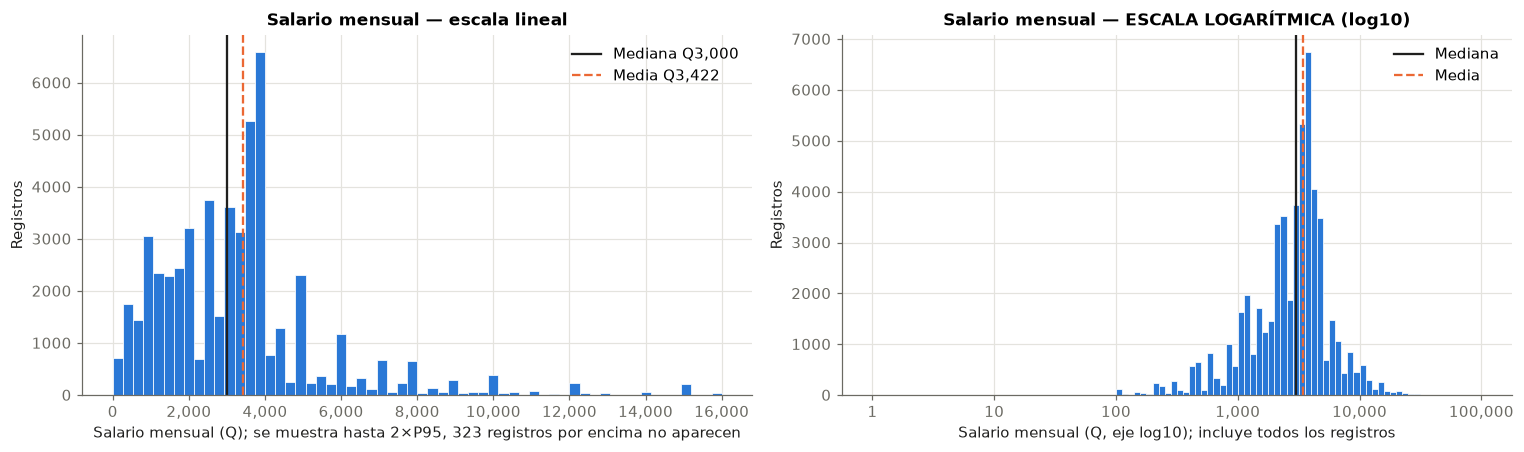

In [14]:
s = desc_2025.loc["salario_mensual"]
print(f"Media: Q{s['media']:,.2f} | Mediana: Q{s['mediana']:,.2f} | "
      f"Diferencia: Q{s['media'] - s['mediana']:,.2f} ({100 * (s['media'] / s['mediana'] - 1):.1f}% sobre la mediana)")
print(f"Asimetría (skewness): {s['asimetria']:.2f} | P95: Q{s['p95']:,.2f} | Máximo: Q{s['max']:,.2f}")

# Histogramas calculados en Spark sobre todos los registros (no sobre una muestra)
LIMITE_LINEAL = float(s["p95"]) * 2
cortes_lin = list(np.linspace(0, LIMITE_LINEAL, 61))
_, frec_lin = (df25.select("salario_mensual").filter(F.col("salario_mensual") <= LIMITE_LINEAL)
               .rdd.flatMap(lambda r: r).histogram(cortes_lin))
log_min = math.floor(math.log10(s["min"]) * 10) / 10
log_max = math.ceil(math.log10(s["max"]) * 10) / 10
cortes_log = list(np.arange(log_min, log_max + 0.05, 0.05))
_, frec_log = df25.select(F.log10("salario_mensual")).rdd.flatMap(lambda r: r).histogram(cortes_log)
fuera = df25.filter(F.col("salario_mensual") > LIMITE_LINEAL).count()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
ax = axes[0]
ax.bar(cortes_lin[:-1], frec_lin, width=np.diff(cortes_lin), align="edge", color=PALETA[0], edgecolor="white", linewidth=0.5)
ax.axvline(s["mediana"], color=TINTA, lw=1.5, ls="-", label=f"Mediana Q{s['mediana']:,.0f}")
ax.axvline(s["media"], color=PALETA[1], lw=1.5, ls="--", label=f"Media Q{s['media']:,.0f}")
ax.set_title("Salario mensual — escala lineal")
ax.set_xlabel(f"Salario mensual (Q); se muestra hasta 2×P95, {fuera:,} registros por encima no aparecen"); ax.set_ylabel("Registros")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(frameon=False)

ax = axes[1]
ax.bar(cortes_log[:-1], frec_log, width=np.diff(cortes_log), align="edge", color=PALETA[0], edgecolor="white", linewidth=0.5)
ax.axvline(math.log10(s["mediana"]), color=TINTA, lw=1.5, label="Mediana")
ax.axvline(math.log10(s["media"]), color=PALETA[1], lw=1.5, ls="--", label="Media")
ax.set_title("Salario mensual — ESCALA LOGARÍTMICA (log10)")
ax.set_xlabel("Salario mensual (Q, eje log10); incluye todos los registros"); ax.set_ylabel("Registros")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{10 ** x:,.0f}"))
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

### 2.3 Salario mediano por nivel educativo y categoría ocupacional

,n,p25,mediana,p75,media
nivel_educativo,,,,,
0 - Ninguno,3995,800.0,1500.0,2400.0,1767.1
1 - Preprimaria,459,1200.0,2160.0,3000.0,2241.9
2 - Primaria,15822,1200.0,2200.0,3200.0,2308.0
3 - Básico,8249,1600.0,2800.0,3600.0,2730.2
4 - Diversificado,16851,2800.0,3600.0,4250.0,3796.4
5 - Superior,6818,3600.0,5000.0,7500.0,5965.3
6 - Maestría,771,6000.0,10000.0,15000.0,11409.3
7 - Doctorado,60,6000.0,12000.0,21000.0,14452.3


,n,p25,mediana,p75,media
categoria_ocupacional,,,,,
1 - Empleado de gobierno,6575,3750.0,5000.0,7380.0,5971.5
2 - Empleado empresa privada,28702,2800.0,3567.5,4000.0,3875.1
3 - Jornalero o peón,13842,1000.0,1800.0,2489.8,1878.6
4 - Servicio doméstico,3906,600.0,1000.0,1600.0,1265.7


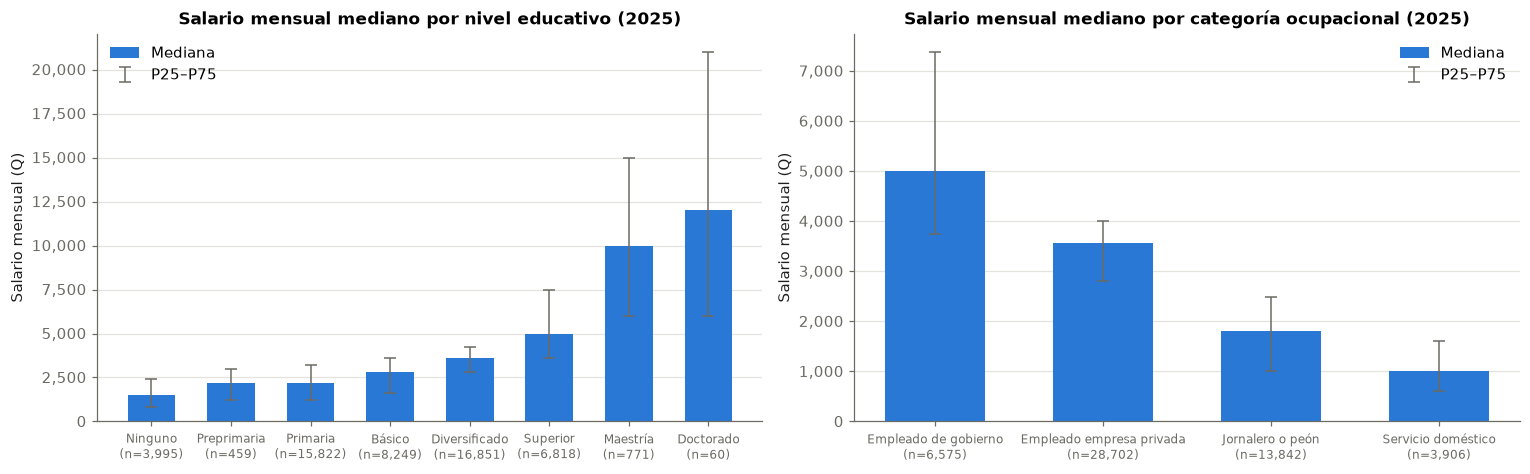

In [15]:
def salario_por_grupo(df, col):
    return (df.groupBy(col).agg(
                F.count(F.lit(1)).alias("n"),
                F.expr("percentile(salario_mensual, array(0.25, 0.5, 0.75))").alias("pct"),
                F.mean("salario_mensual").alias("media"))
            .select(col, "n", F.col("pct")[0].alias("p25"), F.col("pct")[1].alias("mediana"),
                    F.col("pct")[2].alias("p75"), "media")
            .orderBy(col).toPandas().set_index(col))

sal_educ = salario_por_grupo(df25, "nivel_educativo")
sal_cat = salario_por_grupo(df25, "categoria_ocupacional")
display(sal_educ.round(1)); display(sal_cat.round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
for ax, (t, titulo) in zip(axes, [(sal_educ, "Nivel educativo"), (sal_cat, "Categoría ocupacional")]):
    etiquetas = [f"{i.split(' - ', 1)[-1]}\n(n={n:,})" for i, n in zip(t.index, t["n"])]
    x = np.arange(len(t))
    ax.bar(x, t["mediana"], color=PALETA[0], width=0.6, label="Mediana")
    ax.errorbar(x, t["mediana"], yerr=[t["mediana"] - t["p25"], t["p75"] - t["mediana"]],
                fmt="none", ecolor=TINTA_2, capsize=4, lw=1, label="P25–P75")
    ax.set_xticks(x, etiquetas, fontsize=8)
    ax.set_title(f"Salario mensual mediano por {titulo.lower()} (2025)")
    ax.set_ylabel("Salario mensual (Q)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.grid(axis="x", visible=False)
    ax.legend(frameon=False, loc="upper left" if titulo == "Nivel educativo" else "upper right")
plt.tight_layout(); plt.show()

### 2.4 Tamaño de la muestra analítica y salario mediano por trimestre

,n,mediana,media,registros_originales,pct_retenido
periodo_archivo,,,,,
2025T1,13419,3000.0,3315.6,51588,26.0
2025T2,13492,3000.0,3364.6,51167,26.4
2025T3,13450,3200.0,3469.1,51583,26.1
2025T4,12664,3200.0,3544.6,49338,25.7


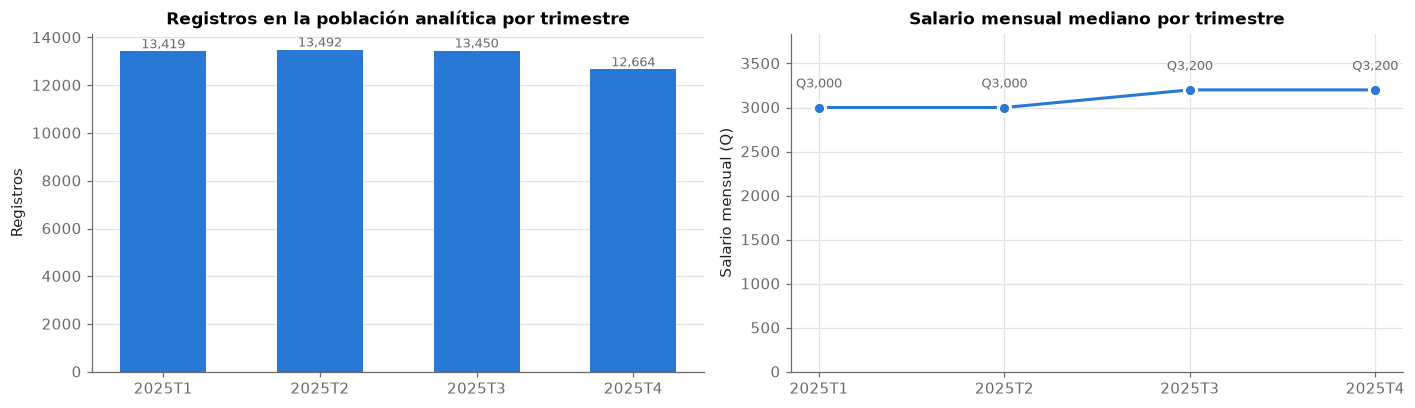

In [16]:
por_trimestre = (df25.groupBy("periodo_archivo").agg(
                    F.count(F.lit(1)).alias("n"),
                    F.expr("percentile(salario_mensual, 0.5)").alias("mediana"),
                    F.mean("salario_mensual").alias("media"))
                 .orderBy("periodo_archivo").toPandas().set_index("periodo_archivo"))
por_trimestre["registros_originales"] = conteo_original["registros_originales"]
por_trimestre["pct_retenido"] = (100 * por_trimestre["n"] / por_trimestre["registros_originales"]).round(2)
display(por_trimestre.round(1))

# Dos medidas con escalas distintas -> dos gráficos (sin doble eje)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].bar(por_trimestre.index, por_trimestre["n"], color=PALETA[0], width=0.55)
for i, v in enumerate(por_trimestre["n"]):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", color=TINTA_2, fontsize=8.5)
axes[0].set_title("Registros en la población analítica por trimestre")
axes[0].set_ylabel("Registros"); axes[0].grid(axis="x", visible=False)
axes[1].plot(por_trimestre.index, por_trimestre["mediana"], color=PALETA[0], lw=2, marker="o", ms=8,
             markeredgecolor="white", markeredgewidth=2)
for i, v in enumerate(por_trimestre["mediana"]):
    axes[1].text(i, v, f"Q{v:,.0f}\n", ha="center", va="bottom", color=TINTA_2, fontsize=8.5)
axes[1].set_title("Salario mensual mediano por trimestre")
axes[1].set_ylabel("Salario mensual (Q)")
axes[1].set_ylim(0, por_trimestre["mediana"].max() * 1.2)   # eje desde cero para no exagerar el cambio
plt.tight_layout(); plt.show()

### 2.5 Interpretación

**Distribución de los registros.** Casi 6 de cada 10 registros son empleados de empresa privada (54.1 %); siguen jornaleros o peones (26.1 %),
gobierno (12.4 %) y servicio doméstico (7.4 %). En educación, Diversificado (31.8 %) y Primaria (29.8 %) reúnen el 61.6 %; Superior es el 12.9 %,
"Ninguno" el 7.5 %, y Maestría (1.45 %) y Doctorado (0.11 %, solo 60 registros) casi no aparecen. Por dominio: Urbano Metropolitano 41.6 %,
Resto Urbano 38.0 % y Rural Nacional 20.4 %. Son proporciones de los registros analizados, no de los trabajadores del país (no se ponderó).

**Simetría del salario.** La distribución es **fuertemente asimétrica a la derecha** (asimetría = 6.00): la mayor parte de los salarios se concentra entre
Q1,800 (P25) y Q4,000 (P75), el P95 es Q8,000 y el máximo llega a Q99,000, unas 12 veces el P95. En escala logarítmica la forma se vuelve mucho más
simétrica, con una moda alrededor de Q3,000–4,000. Se observan picos en cifras redondas (por ejemplo cerca de Q2,500, Q4,000 y Q5,000), lo que
sugiere que muchos salarios se reportan redondeados.

**Media frente a mediana.** La media (Q3,421.68) supera a la mediana (Q3,000.00) en Q421.68, un 14.1 %. La cola de salarios altos arrastra la media hacia arriba, por lo que
la mediana describe mejor el salario típico. Para el modelado esto importa: al conservar el objetivo en quetzales y sin recortar extremos, RMSE
y R² serán sensibles a unos pocos salarios muy altos, mientras que el MAE lo será menos.

**Salario mediano por grupo.** Crece de forma sostenida con el nivel educativo: Q1,500 (Ninguno), Q2,200 (Primaria), Q2,800 (Básico), Q3,600 (Diversificado),
Q5,000 (Superior), Q10,000 (Maestría) y Q12,000 (Doctorado, con solo 60 registros, así que ese valor es poco estable). La dispersión (P25–P75) también se
ensancha con el nivel. Por categoría ocupacional, gobierno tiene la mediana más alta (Q5,000), seguido de empresa privada (Q3,567.50), jornaleros o peones (Q1,800) y servicio
doméstico (Q1,000, con P75 de solo Q1,600). Son asociaciones descriptivas: la educación se mezcla con la categoría ocupacional, la edad y el dominio,
así que no se interpretan como efecto causal.

**Tamaño y salario por trimestre.** La población analítica es estable: 13,419, 13,492, 13,450 y 12,664 registros (alrededor del 26 % de cada archivo); IV-2025 tiene
un 5.8 % menos que III-2025. La mediana pasa de Q3,000 (T1 y T2) a Q3,200 (T3 y T4) y la media de Q3,315.6 a Q3,544.6 (+6.9 %). Con cuatro puntos, sin ajustar por
inflación y sin pruebas estadísticas, esto no permite afirmar una tendencia; solo indica que no hay cambios abruptos entre trimestres, lo que respalda usar
los cuatro de 2025 como conjunto de desarrollo.

---
## 3. Relaciones entre variables numéricas (5 pts)

Se ensamblan las cuatro variables con `VectorAssembler` y se calcula la matriz de correlación de Pearson con
`pyspark.ml.stat.Correlation.corr()` sobre todos los registros elegibles de 2025. Como complemento (no sustituye a Pearson)
se calcula Spearman, que es robusta a la fuerte asimetría del salario.

Pearson:


,salario_mensual,edad,antiguedad,horas_semanales
salario_mensual,1.000,0.147,0.180,0.076
edad,0.147,1.000,0.487,-0.105
antiguedad,0.180,0.487,1.000,-0.062
horas_semanales,0.076,-0.105,-0.062,1.000


Spearman (complemento):


,salario_mensual,edad,antiguedad,horas_semanales
salario_mensual,1.000,0.153,0.261,0.143
edad,0.153,1.000,0.419,-0.120
antiguedad,0.261,0.419,1.000,-0.048
horas_semanales,0.143,-0.120,-0.048,1.000


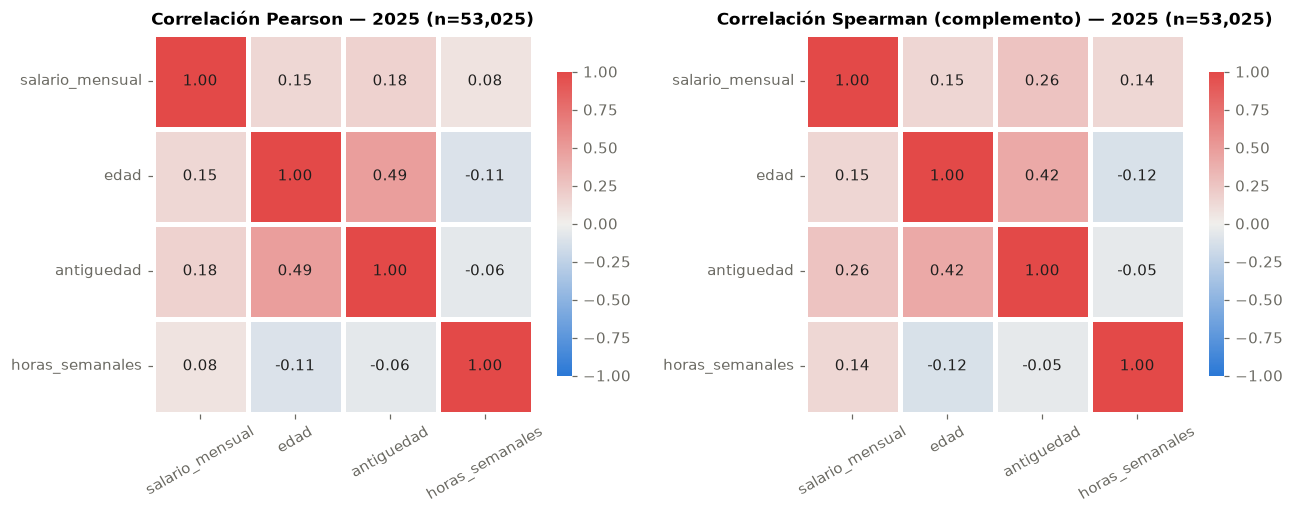

Correlación de Pearson con el salario, de mayor a menor |r|:
antiguedad         0.180
edad               0.147
horas_semanales    0.076


In [17]:
vector_num = VectorAssembler(inputCols=NUMERICAS, outputCol="vec_num").transform(df25).select("vec_num")
corr_pearson = pd.DataFrame(Correlation.corr(vector_num, "vec_num", "pearson").head()[0].toArray(),
                            index=NUMERICAS, columns=NUMERICAS)
corr_spearman = pd.DataFrame(Correlation.corr(vector_num, "vec_num", "spearman").head()[0].toArray(),
                             index=NUMERICAS, columns=NUMERICAS)
print("Pearson:"); display(corr_pearson.round(3))
print("Spearman (complemento):"); display(corr_spearman.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, (m, titulo) in zip(axes, [(corr_pearson, "Pearson"), (corr_spearman, "Spearman (complemento)")]):
    sns.heatmap(m, annot=True, fmt=".2f", cmap=MAPA_DIVERGENTE, vmin=-1, vmax=1, center=0, square=True,
                linewidths=2, linecolor="white", cbar_kws={"shrink": 0.8}, ax=ax,
                annot_kws={"color": TINTA, "fontsize": 10})
    ax.set_title(f"Correlación {titulo} — 2025 (n={df25.count():,})")
    ax.tick_params(axis="x", rotation=30); ax.grid(False)
plt.tight_layout(); plt.show()

print("Correlación de Pearson con el salario, de mayor a menor |r|:")
print(corr_pearson["salario_mensual"].drop("salario_mensual").sort_values(key=abs, ascending=False).round(3).to_string())

### 3.1 Interpretación

**Asociación con el salario.** Todas las asociaciones lineales son **débiles**. La mayor es la antigüedad (Pearson r = 0.180), luego la edad (0.147) y las horas
habituales (0.076). Incluso la antigüedad explica linealmente solo alrededor del 3 % de la varianza del salario (r² ≈ 0.032). Con Spearman, que mide asociación
monótona y es robusta a extremos, las horas suben a 0.143 y la antigüedad a 0.261, lo que indica que la relación existe pero no es lineal y que los salarios extremos
deprimen el coeficiente de Pearson. Ninguna de las tres variables numéricas basta por sí sola para estimar el salario; es de esperar que las categóricas
(educación, categoría ocupacional) aporten más, como sugiere el ejercicio 2.

**Edad y antigüedad.** Sí hay relación: r = 0.487 con Pearson (0.419 con Spearman), positiva y moderada. Es esperable, porque la antigüedad no puede superar la edad
(filtro 7) y quien tiene más edad ha tenido más tiempo para acumular antigüedad. No es más alta porque hay muchas personas mayores con poca antigüedad
(posiblemente por cambios de empleo), como se ve en el diagrama de dispersión del ejercicio 4. Esta colinealidad moderada es tolerable en la regresión lineal y otro motivo para regularizar.

Las horas semanales tienen correlaciones negativas débiles con la edad (−0.105) y la antigüedad (−0.062): las personas mayores tienden a trabajar algo menos horas.
Recordar que la correlación mide solo asociación lineal y no implica causalidad.

---
## 4. Segmentación de perfiles con KMeans (10 pts)

**Variables.** La segmentación busca perfiles laborales, así que se usan las tres variables numéricas continuas:
`edad`, `antiguedad` y `horas_semanales`. Se comparan dos variantes:

* **A — sin salario:** edad, antigüedad, horas.
* **B — con salario:** las mismas + `log10(salario)`. Se usa el logaritmo *solo para el clustering* porque, con la escala original,
  la cola larga del salario dominaría la distancia euclidiana incluso después de estandarizar.

Todas las variables se **estandarizan** (`StandardScaler` con media 0 y desviación 1) porque KMeans usa distancias y
las variables tienen escalas muy distintas (años vs. horas vs. quetzales). Se prueban **K = 2, 3, 4 y 5** con semilla fija.

**Criterio para elegir K (acordado como grupo):** mayor coeficiente de **silueta**, siempre que ningún clúster tenga menos del **5 %**
de los registros (para que cada perfil sea interpretable); el codo del WSSSE se usa como apoyo visual.

,variante,K,silueta,WSSSE,pct_cluster_min,tamanos
0,A: sin salario,2,0.5547,106717.3861,27.5078,"[38439, 14586]"
1,A: sin salario,3,0.4721,83608.0574,19.0250,"[31112, 11825, 10088]"
2,A: sin salario,4,0.4763,64438.3407,12.9448,"[24511, 12745, 8905, 6864]"
3,A: sin salario,5,0.4914,56848.4537,4.9316,"[24120, 10291, 8472, 7527, 2615]"
4,B: con log-salario,2,0.4112,171215.4850,22.9439,"[40859, 12166]"
5,B: con log-salario,3,0.3127,135120.9852,21.7256,"[28963, 12542, 11520]"
6,B: con log-salario,4,0.4133,107386.1192,15.1117,"[27458, 8995, 8559, 8013]"
7,B: con log-salario,5,0.3867,91787.8756,10.9816,"[21052, 12806, 6752, 6592, 5823]"


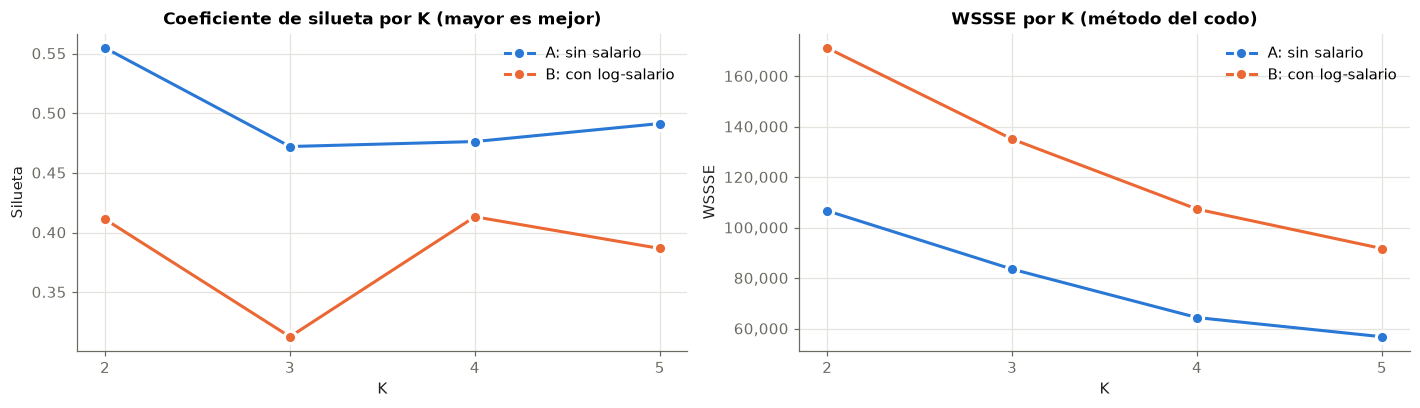

In [18]:
VARS_A = ["edad", "antiguedad", "horas_semanales"]
VARS_B = VARS_A + ["log_salario"]
K_VALORES = [2, 3, 4, 5]
MIN_PCT_CLUSTER = 5.0

df25_km = df25.withColumn("log_salario", F.log10("salario_mensual"))
evaluador = ClusteringEvaluator(featuresCol="features", predictionCol="cluster",
                                metricName="silhouette", distanceMeasure="squaredEuclidean")

def preparar_escalado(df, variables):
    etapas = [VectorAssembler(inputCols=variables, outputCol="x_crudo"),
              StandardScaler(inputCol="x_crudo", outputCol="features", withMean=True, withStd=True)]
    modelo = Pipeline(stages=etapas).fit(df)
    return modelo, modelo.transform(df).cache()

def evaluar_k(datos, variante):
    filas, modelos = [], {}
    total = datos.count()
    for k in K_VALORES:
        km = KMeans(k=k, seed=SEED, featuresCol="features", predictionCol="cluster", maxIter=100)
        modelo = km.fit(datos)
        pred = modelo.transform(datos)
        tamanos = modelo.summary.clusterSizes
        filas.append({"variante": variante, "K": k, "silueta": evaluador.evaluate(pred),
                      "WSSSE": modelo.summary.trainingCost,
                      "pct_cluster_min": 100 * min(tamanos) / total,
                      "tamanos": sorted(tamanos, reverse=True)})
        modelos[k] = modelo
    return pd.DataFrame(filas), modelos

escalador_A, datos_A = preparar_escalado(df25_km, VARS_A)
escalador_B, datos_B = preparar_escalado(df25_km, VARS_B)
res_A, modelos_A = evaluar_k(datos_A, "A: sin salario")
res_B, modelos_B = evaluar_k(datos_B, "B: con log-salario")
resultados_km = pd.concat([res_A, res_B], ignore_index=True)
display(resultados_km.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for i, (res, nombre) in enumerate([(res_A, "A: sin salario"), (res_B, "B: con log-salario")]):
    color = PALETA[i]
    axes[0].plot(res["K"], res["silueta"], marker="o", ms=8, lw=2, color=color, label=nombre,
                 markeredgecolor="white", markeredgewidth=2)
    axes[1].plot(res["K"], res["WSSSE"], marker="o", ms=8, lw=2, color=color, label=nombre,
                 markeredgecolor="white", markeredgewidth=2)
axes[0].set_title("Coeficiente de silueta por K (mayor es mejor)"); axes[0].set_xlabel("K"); axes[0].set_ylabel("Silueta")
axes[1].set_title("WSSSE por K (método del codo)"); axes[1].set_xlabel("K"); axes[1].set_ylabel("WSSSE")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
for ax in axes:
    ax.set_xticks(K_VALORES); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

In [19]:
def elegir_k(res):
    validos = res[res["pct_cluster_min"] >= MIN_PCT_CLUSTER]
    return int(validos.sort_values("silueta", ascending=False).iloc[0]["K"])

K_A, K_B = elegir_k(res_A), elegir_k(res_B)
print(f"Variante A (sin salario): K elegido = {K_A}, silueta = {res_A.set_index('K').loc[K_A, 'silueta']:.4f}")
print(f"Variante B (con salario): K elegido = {K_B}, silueta = {res_B.set_index('K').loc[K_B, 'silueta']:.4f}")

# ¿Qué tan parecidas son las particiones A y B? (tabla cruzada)
pred_A = modelos_A[K_A].transform(datos_A).select("NUM_HOGAR", "NUM_PERSONA", "periodo_archivo", F.col("cluster").alias("cluster_A"))
pred_B = modelos_B[K_B].transform(datos_B).select("NUM_HOGAR", "NUM_PERSONA", "periodo_archivo", F.col("cluster").alias("cluster_B"))
print("Tabla cruzada de asignaciones (filas: A sin salario, columnas: B con salario):")
display(pred_A.join(pred_B, ["NUM_HOGAR", "NUM_PERSONA", "periodo_archivo"])
        .groupBy("cluster_A").pivot("cluster_B").count().orderBy("cluster_A").toPandas().set_index("cluster_A"))

Variante A (sin salario): K elegido = 2, silueta = 0.5547
Variante B (con salario): K elegido = 4, silueta = 0.4133
Tabla cruzada de asignaciones (filas: A sin salario, columnas: B con salario):


,0,1,2,3
cluster_A,,,,
0,NaN,25146,7262,6031
1,8995.0,2312,751,2528


### 4.1 ¿Vale la pena incluir el salario?

Se decide **no incluir el salario** en la segmentación final (variante A) y usarlo solo para **describir** los clústeres ex post:

1. **Objetivo del análisis.** La pregunta es qué perfiles de trabajadores existen según edad, antigüedad y jornada; el salario es el
   resultado que después se quiere explicar. Si el salario define los grupos, la conclusión "el clúster X gana más" es circular.
2. **Coherencia con la Parte 2.** El salario es la variable objetivo de los modelos supervisados. Segmentar con él y luego
   comparar salarios entre segmentos mezclaría variable objetivo y descripción (la etiqueta de clúster tampoco puede ser predictor).
3. **Escala.** Aun estandarizado, el salario original es muy asimétrico: unos pocos salarios extremos generan clústeres pequeños
   de valores atípicos. Por eso la variante B necesita el logaritmo.
4. **Evidencia empírica.** Las métricas de la tabla anterior (silueta, tamaño mínimo de clúster y la tabla cruzada) muestran cuánto
   cambia la partición al agregar el salario; la comparación se comenta en la interpretación final.

In [20]:
K_FINAL = K_A
modelo_final = modelos_A[K_FINAL]
segmentado = modelo_final.transform(datos_A).drop("x_crudo", "features").cache()

total = segmentado.count()
perfil = (segmentado.groupBy("cluster").agg(
            F.count(F.lit(1)).alias("n"),
            F.mean("edad").alias("edad_media"), F.expr("percentile(edad, 0.5)").alias("edad_mediana"),
            F.mean("antiguedad").alias("antig_media"), F.expr("percentile(antiguedad, 0.5)").alias("antig_mediana"),
            F.mean("horas_semanales").alias("horas_media"), F.expr("percentile(horas_semanales, 0.5)").alias("horas_mediana"),
            F.expr("percentile(salario_mensual, 0.5)").alias("salario_mediano"),
            F.mean("salario_mensual").alias("salario_medio"),
            F.mean((F.col("nivel_educativo_cod") >= 5).cast("double")).alias("pct_superior_o_mas"),
            F.mean((F.col("nivel_educativo_cod") <= 2).cast("double")).alias("pct_primaria_o_menos"),
            F.mean((F.col("dominio_cod") == 3).cast("double")).alias("pct_rural"))
          .orderBy("cluster").toPandas().set_index("cluster"))
perfil.insert(1, "pct_registros", 100 * perfil["n"] / total)
for c in ["pct_superior_o_mas", "pct_primaria_o_menos", "pct_rural"]:
    perfil[c] = 100 * perfil[c]

def composicion(col):
    t = segmentado.groupBy("cluster", col).count().toPandas().pivot(index="cluster", columns=col, values="count").fillna(0)
    return (100 * t.div(t.sum(axis=1), axis=0)).round(1)

print(f"Perfil de los {K_FINAL} clústeres (variante A, 2025, n={total:,}):")
display(perfil.round(1))
print("Composición por categoría ocupacional (% dentro de cada clúster):"); display(composicion("categoria_ocupacional"))
print("Composición por nivel educativo (% dentro de cada clúster):"); display(composicion("nivel_educativo"))
print("Composición por dominio (% dentro de cada clúster):"); display(composicion("dominio"))

Perfil de los 2 clústeres (variante A, 2025, n=53,025):


,n,pct_registros,edad_media,edad_mediana,antig_media,antig_mediana,horas_media,horas_mediana,salario_mediano,salario_medio,pct_superior_o_mas,pct_primaria_o_menos,pct_rural
cluster,,,,,,,,,,,,,
0,38439,72.5,29.1,28.0,2.4,1.3,48.2,46.0,3000.0,3175.7,12.4,34.5,21.7
1,14586,27.5,51.3,51.0,13.8,13.0,41.3,40.0,3468.0,4070.0,19.8,48.2,17.0


Composición por categoría ocupacional (% dentro de cada clúster):


categoria_ocupacional,1 - Empleado de gobierno,2 - Empleado empresa privada,3 - Jornalero o peón,4 - Servicio doméstico
cluster,,,,
0,8.2,58.5,26.8,6.5
1,23.5,42.5,24.3,9.6


Composición por nivel educativo (% dentro de cada clúster):


nivel_educativo,0 - Ninguno,1 - Preprimaria,2 - Primaria,3 - Básico,4 - Diversificado,5 - Superior,6 - Maestría,7 - Doctorado
cluster,,,,,,,,
0,4.9,0.8,28.8,17.8,35.3,11.3,1.1,0.0
1,14.5,1.2,32.5,9.6,22.5,17.1,2.4,0.3


Composición por dominio (% dentro de cada clúster):


dominio,1 - Urbano Metropolitano,2 - Resto Urbano,3 - Rural Nacional
cluster,,,
0,40.2,38.2,21.7
1,45.5,37.5,17.0


Clúster 0 (72.5%): Trabajadores más jóvenes que el promedio, con poca antigüedad, jornada típica, salario mediano similar al global (+0%)
Clúster 1 (27.5%): Trabajadores mayores que el promedio, con alta antigüedad, jornada típica, salario mediano superior al global (+16%)


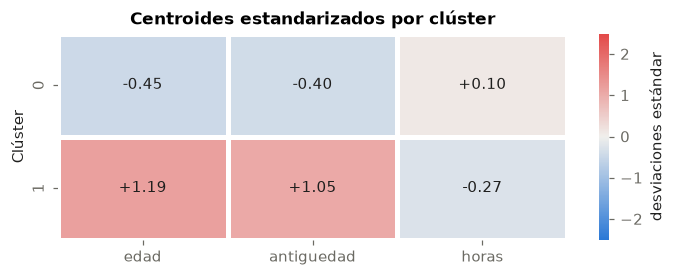

In [21]:
# Centroides en unidades estandarizadas (z): cuántas desviaciones estándar se aleja cada clúster de la media global
centros_z = pd.DataFrame(modelo_final.clusterCenters(), columns=VARS_A)
mediana_global = desc_2025.loc["salario_mensual", "mediana"]
centros_z["salario_mediano_rel"] = perfil["salario_mediano"].values / mediana_global - 1

def describir(fila, sal):
    rasgos = []
    rasgos.append("mayores que el promedio" if fila["edad"] > 0.5 else
                  "más jóvenes que el promedio" if fila["edad"] < -0.3 else "de edad promedio")
    rasgos.append("con alta antigüedad" if fila["antiguedad"] > 0.5 else
                  "con poca antigüedad" if fila["antiguedad"] < -0.3 else "con antigüedad media")
    rasgos.append("jornada extensa" if fila["horas_semanales"] > 0.5 else
                  "jornada parcial/corta" if fila["horas_semanales"] < -0.5 else "jornada típica")
    rasgos.append(f"salario mediano {'superior' if sal > 0.05 else 'inferior' if sal < -0.05 else 'similar'} "
                  f"al global ({100 * sal:+.0f}%)")
    return "Trabajadores " + ", ".join(rasgos)

for k in range(K_FINAL):
    print(f"Clúster {k} ({perfil.loc[k, 'pct_registros']:.1f}%): {describir(centros_z.loc[k], centros_z.loc[k, 'salario_mediano_rel'])}")

fig, ax = plt.subplots(figsize=(6.5, 0.6 * K_FINAL + 1.4))
sns.heatmap(centros_z[VARS_A].rename(columns={"horas_semanales": "horas"}), annot=True, fmt="+.2f",
            cmap=MAPA_DIVERGENTE, center=0, vmin=-2.5, vmax=2.5, linewidths=2, linecolor="white",
            annot_kws={"color": TINTA}, cbar_kws={"label": "desviaciones estándar"}, ax=ax)
ax.set_title("Centroides estandarizados por clúster"); ax.set_ylabel("Clúster"); ax.grid(False)
plt.tight_layout(); plt.show()

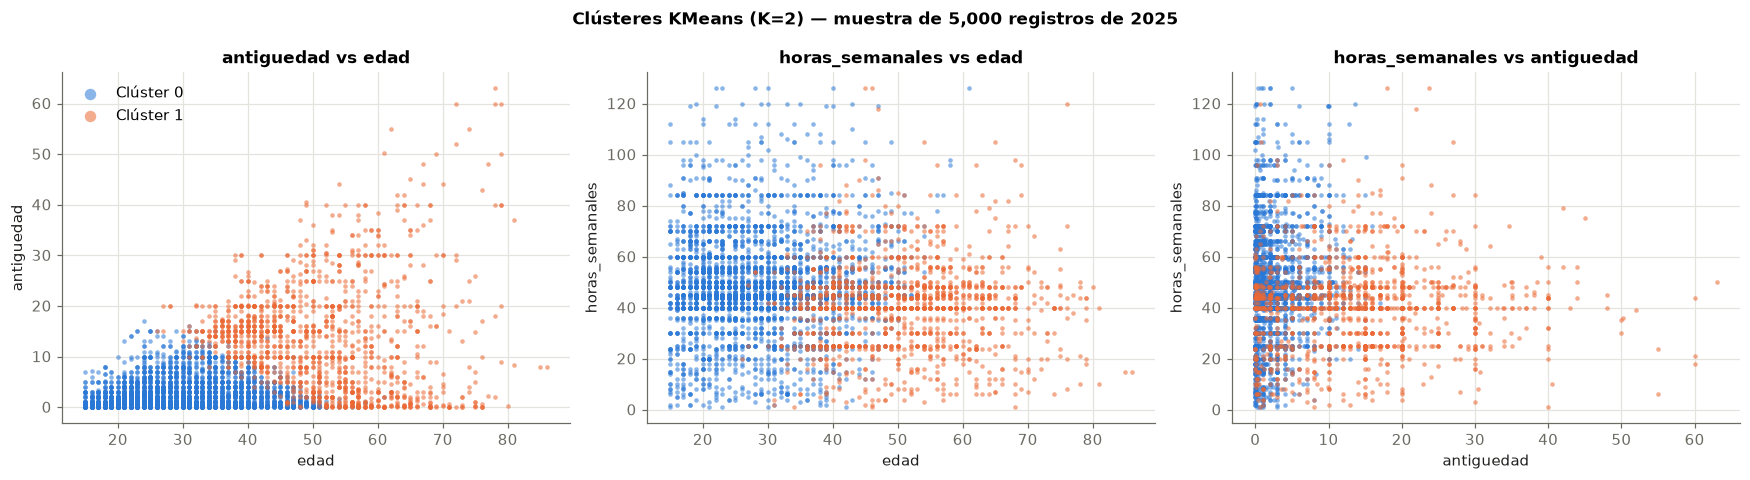

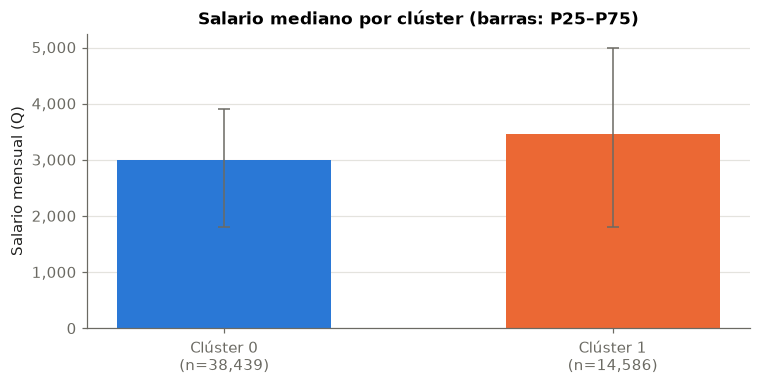

In [22]:
# Visualización con una muestra de hasta 5,000 registros (las métricas se calcularon con todos)
muestra = (segmentado.sample(fraction=min(1.0, 5500 / total), seed=SEED).limit(5000)
           .select("edad", "antiguedad", "horas_semanales", "salario_mensual", "cluster").toPandas())

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
pares = [("edad", "antiguedad"), ("edad", "horas_semanales"), ("antiguedad", "horas_semanales")]
for ax, (x, y) in zip(axes, pares):
    for k in range(K_FINAL):
        m = muestra[muestra["cluster"] == k]
        ax.scatter(m[x], m[y], s=9, alpha=0.55, color=PALETA[k], label=f"Clúster {k}", linewidths=0)
    ax.set_xlabel(x); ax.set_ylabel(y); ax.set_title(f"{y} vs {x}")
axes[0].legend(frameon=False, markerscale=2.5)
fig.suptitle(f"Clústeres KMeans (K={K_FINAL}) — muestra de {len(muestra):,} registros de 2025", fontweight="bold")
plt.tight_layout(); plt.show()

# Salario por clúster (percentiles calculados sobre todos los registros)
sal_cluster = salario_por_grupo(segmentado, "cluster")
fig, ax = plt.subplots(figsize=(7, 3.6))
x = np.arange(K_FINAL)
ax.bar(x, sal_cluster["mediana"], color=[PALETA[k] for k in range(K_FINAL)], width=0.55)
ax.errorbar(x, sal_cluster["mediana"], yerr=[sal_cluster["mediana"] - sal_cluster["p25"], sal_cluster["p75"] - sal_cluster["mediana"]],
            fmt="none", ecolor=TINTA_2, capsize=4, lw=1)
ax.set_xticks(x, [f"Clúster {k}\n(n={n:,})" for k, n in zip(sal_cluster.index, sal_cluster["n"])])
ax.set_ylabel("Salario mensual (Q)"); ax.set_title("Salario mediano por clúster (barras: P25–P75)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}")); ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

### 4.2 Descripción de los clústeres

**K elegido: 2.** Con el criterio definido (mayor silueta con ningún clúster menor al 5 %), K = 2 obtiene la silueta más alta (0.555, frente a 0.472, 0.476 y 0.491
para K = 3, 4 y 5) y gana aunque no se aplicara la regla del 5 % (con K = 5 el clúster más pequeño tiene 4.9 %). El WSSSE baja de forma continua (106,717 → 83,608 → 64,438 → 56,848)
sin un codo claro, así que el codo no contradice ni respalda la elección.

| Clúster | Descripción | Registros | Edad (media / mediana) | Antigüedad | Horas | Salario mediano |
|---|---|---|---|---|---|---|
| 0 | **Trabajadores jóvenes con poca antigüedad** | 38,439 (72.5 %) | 29.1 / 28 | 2.4 / 1.3 años | 48.2 / 46 | Q3,000 (media Q3,176) |
| 1 | **Trabajadores mayores con larga trayectoria** | 14,586 (27.5 %) | 51.3 / 51 | 13.8 / 13 años | 41.3 / 40 | Q3,468 (media Q4,070) |

* **Clúster 0:** 58.5 % en empresa privada, 26.8 % jornaleros y 8.2 % gobierno; 12.4 % con educación superior o más y 34.5 % con primaria o menos; 21.7 % en dominio rural.
* **Clúster 1:** 23.5 % en gobierno, 42.5 % en empresa privada y 24.3 % jornaleros; 19.8 % con educación superior o más, pero también 48.2 % con primaria o menos (14.5 % sin ningún nivel); 17.0 % en dominio rural.
  Es un grupo más heterogéneo: incluye tanto a quienes tienen mayor educación y empleo público como a quienes tienen menos escolaridad.
* El eje principal de la separación es la **etapa laboral** (edad y antigüedad, con centroides de −0.45 y −0.40 frente a +1.19 y +1.05 desviaciones estándar). Las horas pesan poco: el clúster 1 trabaja unas 7 horas menos a la semana.
  El salario mediano del clúster 1 es 16 % mayor, con una dispersión superior hacia arriba (su P75 es más alto en el gráfico).

**¿Vale la pena incluir el salario?** No, según lo observado. Agregar `log10(salario)` **baja la silueta en todos los K** (K = 2: 0.411 frente a 0.555; K = 3: 0.313 frente a 0.472; K = 4: 0.413 frente a 0.476; K = 5: 0.387 frente a 0.491).
En la tabla cruzada, la variante con salario reparte a los trabajadores jóvenes (clúster 0 sin salario) en tres clústeres (25,146, 7,262 y 6,031) y mezcla el resto, lo que sugiere que esa variante agrupa más por nivel de ingreso que por perfil laboral.
Además, usarlo para formar los grupos volvería circular la comparación de salarios entre clústeres y contaminaría el uso posterior del salario como variable objetivo. Por eso se segmenta sin salario y este se usa solo para describir los grupos.

**Limitaciones.** K = 2 es una partición gruesa: el diagrama de dispersión muestra que la frontera entre ambos clústeres es difusa y se solapan entre los 35 y 45 años, por lo que los datos se parecen más a un continuo que a grupos bien separados
(la silueta de 0.55 indica una estructura moderada). K = 4 (silueta 0.476, clúster mínimo 12.9 %) daría perfiles más finos, pero el criterio acordado no lo respalda. KMeans usa promedios y es sensible a valores extremos
(antigüedades de hasta 70 años). Los grupos describen los registros analizados (no ponderados) y no son estimaciones de la población.

---
## 5. Pipeline de regresión lineal (20 pts)

Para validar sin filtrar información del futuro, se reservan **2025T1–2025T3** para entrenamiento y **2025T4** para validación. El trimestre 2026T1 sigue totalmente reservado para la prueba final. Los seis predictores son exactamente los indicados: tres numéricos y tres categóricos.

El referente es una predicción constante: la mediana de salario del entrenamiento. Se reportan MAE, RMSE y R² sobre todos los registros de validación, sin ponderar. Un residuo se define como `salario real − predicción`; por tanto, uno positivo indica subestimación.

In [23]:
# Partición temporal fija y predictores permitidos por el enunciado
PREDICTORES_NUM = ["edad", "antiguedad", "horas_semanales"]
PREDICTORES_CAT = ["nivel_educativo", "categoria_ocupacional", "dominio"]
ETIQUETA = "salario_mensual"

entrenamiento = preparado_2025.filter(F.col("periodo_archivo").isin("2025T1", "2025T2", "2025T3")).cache()
validacion = preparado_2025.filter(F.col("periodo_archivo") == "2025T4").cache()
prueba_2026 = preparado_2026.withColumn("id_prueba", F.monotonically_increasing_id()).cache()
n_train, n_val, n_test = entrenamiento.count(), validacion.count(), prueba_2026.count()
print(f"Entrenamiento temporal: 2025T1–T3 = {n_train:,} | Validación: 2025T4 = {n_val:,} | Prueba reservada: 2026T1 = {n_test:,}")

def medir(predicciones, nombre):
    con_error = predicciones.withColumn("residuo", F.col(ETIQUETA) - F.col("prediction"))
    return {
        "modelo": nombre,
        "n": con_error.count(),
        "MAE": RegressionEvaluator(labelCol=ETIQUETA, predictionCol="prediction", metricName="mae").evaluate(con_error),
        "RMSE": RegressionEvaluator(labelCol=ETIQUETA, predictionCol="prediction", metricName="rmse").evaluate(con_error),
        "R2": RegressionEvaluator(labelCol=ETIQUETA, predictionCol="prediction", metricName="r2").evaluate(con_error),
        "error_medio": con_error.agg(F.mean("residuo").alias("e")).first()["e"]
    }

def pipeline_lineal(reg_param, elastic_net):
    idx = [f"{c}__idx" for c in PREDICTORES_CAT]
    ohe = [f"{c}__ohe" for c in PREDICTORES_CAT]
    return Pipeline(stages=[
        StringIndexer(inputCols=PREDICTORES_CAT, outputCols=idx, handleInvalid="keep"),
        OneHotEncoder(inputCols=idx, outputCols=ohe, handleInvalid="keep"),
        VectorAssembler(inputCols=PREDICTORES_NUM + ohe, outputCol="features", handleInvalid="keep"),
        LinearRegression(featuresCol="features", labelCol=ETIQUETA, predictionCol="prediction",
                         regParam=reg_param, elasticNetParam=elastic_net, standardization=True, maxIter=200)
    ])

# La referencia se ajusta únicamente con entrenamiento.
mediana_train = entrenamiento.selectExpr(f"percentile({ETIQUETA}, 0.5) as mediana").first()["mediana"]
pred_referencia_val = validacion.withColumn("prediction", F.lit(float(mediana_train)))
metrica_referencia_val = medir(pred_referencia_val, "Referencia: mediana entrenamiento")
print(f"Referencia: siempre predecir Q{mediana_train:,.2f} (mediana de 2025T1–T3).")

Entrenamiento temporal: 2025T1–T3 = 40,361 | Validación: 2025T4 = 12,664 | Prueba reservada: 2026T1 = 13,258
Referencia: siempre predecir Q3,000.00 (mediana de 2025T1–T3).


In [24]:
# Dos configuraciones de regularización; se elige por el menor RMSE de validación.
CONFIGS_LR = [
    {"nombre": "Ridge: regParam=0.01, elasticNet=0.0", "regParam": 0.01, "elasticNetParam": 0.0},
    {"nombre": "Elastic Net: regParam=0.10, elasticNet=0.5", "regParam": 0.10, "elasticNetParam": 0.5},
]
resultados_lr, modelos_lr_dev = [], {}
for cfg in CONFIGS_LR:
    modelo = pipeline_lineal(cfg["regParam"], cfg["elasticNetParam"]).fit(entrenamiento)
    metricas = medir(modelo.transform(validacion), cfg["nombre"])
    metricas.update({"regParam": cfg["regParam"], "elasticNetParam": cfg["elasticNetParam"]})
    resultados_lr.append(metricas)
    modelos_lr_dev[cfg["nombre"]] = modelo

tabla_lr = pd.DataFrame([metrica_referencia_val] + resultados_lr)
display(tabla_lr[["modelo", "n", "MAE", "RMSE", "R2", "error_medio", "regParam", "elasticNetParam"]].round(3))
mejor_lr = min(resultados_lr, key=lambda x: x["RMSE"])
print(f"Mejor regresión lineal: {mejor_lr['modelo']} | RMSE validación: Q{mejor_lr['RMSE']:,.2f}.")
print(f"Frente a la referencia, el RMSE cambia de Q{metrica_referencia_val['RMSE']:,.2f} a Q{mejor_lr['RMSE']:,.2f}.")

,modelo,n,MAE,RMSE,R2,error_medio,regParam,elasticNetParam
0,Referencia: mediana entrenamiento,12664,1670.390,2936.004,-0.036,544.575,NaN,NaN
1,"Ridge: regParam=0.01, elasticNet=0.0",12664,1210.137,2186.420,0.426,111.496,0.01,0.0
2,"Elastic Net: regParam=0.10, elasticNet=0.5",12664,1210.107,2186.425,0.426,111.498,0.10,0.5


Mejor regresión lineal: Ridge: regParam=0.01, elasticNet=0.0 | RMSE validación: Q2,186.42.
Frente a la referencia, el RMSE cambia de Q2,936.00 a Q2,186.42.


### Interpretación de la regresión lineal

La tabla anterior compara configuraciones entrenadas exclusivamente con 2025T1–T3. Se escoge la de menor RMSE porque penaliza más los errores grandes, relevantes dada la cola alta de salarios. Un R² mayor que cero y menores MAE/RMSE que la referencia indican aporte predictivo de las características; aun así, los resultados describen asociación predictiva, no causalidad.

---
## 6. Pipeline de Random Forest (20 pts)

Se conserva exactamente la misma partición temporal y la misma codificación de categorías. Random Forest no requiere estandarizar predictores: las particiones de los árboles dependen del orden y de umbrales, no de distancias. Se usa una semilla fija para reproducibilidad.

In [25]:
def pipeline_bosque(num_trees, max_depth):
    idx = [f"{c}__idx" for c in PREDICTORES_CAT]
    ohe = [f"{c}__ohe" for c in PREDICTORES_CAT]
    return Pipeline(stages=[
        StringIndexer(inputCols=PREDICTORES_CAT, outputCols=idx, handleInvalid="keep"),
        OneHotEncoder(inputCols=idx, outputCols=ohe, handleInvalid="keep"),
        VectorAssembler(inputCols=PREDICTORES_NUM + ohe, outputCol="features", handleInvalid="keep"),
        RandomForestRegressor(featuresCol="features", labelCol=ETIQUETA, predictionCol="prediction",
                              numTrees=num_trees, maxDepth=max_depth, seed=SEED, maxBins=32)
    ])

CONFIGS_RF = [
    {"nombre": "RF: 60 árboles, profundidad 6", "numTrees": 60, "maxDepth": 6},
    {"nombre": "RF: 100 árboles, profundidad 8", "numTrees": 100, "maxDepth": 8},
]
resultados_rf, modelos_rf_dev = [], {}
for cfg in CONFIGS_RF:
    modelo = pipeline_bosque(cfg["numTrees"], cfg["maxDepth"]).fit(entrenamiento)
    metricas = medir(modelo.transform(validacion), cfg["nombre"])
    metricas.update({"numTrees": cfg["numTrees"], "maxDepth": cfg["maxDepth"]})
    resultados_rf.append(metricas)
    modelos_rf_dev[cfg["nombre"]] = modelo

tabla_rf = pd.DataFrame([metrica_referencia_val] + resultados_rf)
display(tabla_rf[["modelo", "n", "MAE", "RMSE", "R2", "error_medio", "numTrees", "maxDepth"]].round(3))
mejor_rf = min(resultados_rf, key=lambda x: x["RMSE"])
print(f"Mejor Random Forest: {mejor_rf['modelo']} | RMSE validación: Q{mejor_rf['RMSE']:,.2f}.")

comparacion_validacion = pd.DataFrame([metrica_referencia_val, mejor_lr, mejor_rf])
display(comparacion_validacion[["modelo", "MAE", "RMSE", "R2", "error_medio"]].round(3))
ganador_val = min([mejor_lr, mejor_rf], key=lambda x: x["RMSE"])
print(f"En validación gana {ganador_val['modelo']} por RMSE. Los árboles pueden capturar umbrales e interacciones; la regresión lineal impone efectos aditivos lineales.")

,modelo,n,MAE,RMSE,R2,error_medio,numTrees,maxDepth
0,Referencia: mediana entrenamiento,12664,1670.390,2936.004,-0.036,544.575,NaN,NaN
1,"RF: 60 árboles, profundidad 6",12664,1127.850,2107.542,0.466,90.328,60.0,6.0
2,"RF: 100 árboles, profundidad 8",12664,1094.532,2032.754,0.504,98.704,100.0,8.0


Mejor Random Forest: RF: 100 árboles, profundidad 8 | RMSE validación: Q2,032.75.


,modelo,MAE,RMSE,R2,error_medio
0,Referencia: mediana entrenamiento,1670.390,2936.004,-0.036,544.575
1,"Ridge: regParam=0.01, elasticNet=0.0",1210.137,2186.420,0.426,111.496
2,"RF: 100 árboles, profundidad 8",1094.532,2032.754,0.504,98.704


En validación gana RF: 100 árboles, profundidad 8 por RMSE. Los árboles pueden capturar umbrales e interacciones; la regresión lineal impone efectos aditivos lineales.


---
## 7. Entrenamiento final y evaluación en 2026 (20 pts)

Después de seleccionar una configuración por algoritmo con 2025T4, cada pipeline se vuelve a ajustar con **todos los registros preparados de 2025**. Los dos modelos se aplican al mismo `prueba_2026`, preparado con las mismas reglas y sin reentrenar componentes. Se guardan tanto los modelos de desarrollo como los finales en `data/modelos/`.

In [26]:
MODELOS_DIR = DATA_DIR / "modelos"
MODELOS_DIR.mkdir(parents=True, exist_ok=True)

# Se conservan los mejores modelos ajustados solo en desarrollo para auditoría.
modelos_lr_dev[mejor_lr["modelo"]].write().overwrite().save(str(MODELOS_DIR / "regresion_lineal_desarrollo"))
modelos_rf_dev[mejor_rf["modelo"]].write().overwrite().save(str(MODELOS_DIR / "random_forest_desarrollo"))

modelo_lr_final = pipeline_lineal(mejor_lr["regParam"], mejor_lr["elasticNetParam"]).fit(preparado_2025)
modelo_rf_final = pipeline_bosque(int(mejor_rf["numTrees"]), int(mejor_rf["maxDepth"])).fit(preparado_2025)
modelo_lr_final.write().overwrite().save(str(MODELOS_DIR / "regresion_lineal_final_2025"))
modelo_rf_final.write().overwrite().save(str(MODELOS_DIR / "random_forest_final_2025"))

pred_lr_2026 = modelo_lr_final.transform(prueba_2026).cache()
pred_rf_2026 = modelo_rf_final.transform(prueba_2026).cache()
mediana_2025 = preparado_2025.selectExpr(f"percentile({ETIQUETA}, 0.5) as mediana").first()["mediana"]
pred_ref_2026 = prueba_2026.withColumn("prediction", F.lit(float(mediana_2025)))

metricas_2026 = pd.DataFrame([
    medir(pred_ref_2026, "Referencia: mediana 2025"),
    medir(pred_lr_2026, "Regresión lineal final"),
    medir(pred_rf_2026, "Random Forest final"),
])
display(metricas_2026[["modelo", "n", "MAE", "RMSE", "R2", "error_medio"]].round(3))
assert pred_lr_2026.select("id_prueba").distinct().count() == pred_rf_2026.select("id_prueba").distinct().count() == n_test
print(f"Los dos modelos se evaluaron sobre los mismos {n_test:,} registros elegibles de 2026T1. Modelos guardados en: {MODELOS_DIR}")

,modelo,n,MAE,RMSE,R2,error_medio
0,Referencia: mediana 2025,13258,1718.678,2923.083,-0.039,565.796
1,Regresión lineal final,13258,1240.710,2163.752,0.431,120.551
2,Random Forest final,13258,1124.251,2013.102,0.507,108.416


Los dos modelos se evaluaron sobre los mismos 13,258 registros elegibles de 2026T1. Modelos guardados en: ../data/modelos


---
## 8. Visualización y análisis de errores (15 pts)

Las métricas por grupo se calculan sobre el conjunto completo de 2026T1. Para los gráficos se toma una única muestra aleatoria reproducible de hasta 5,000 identificadores de prueba, compartida por ambos modelos. Así, las diferencias visuales no provienen de haber mostrado personas distintas.

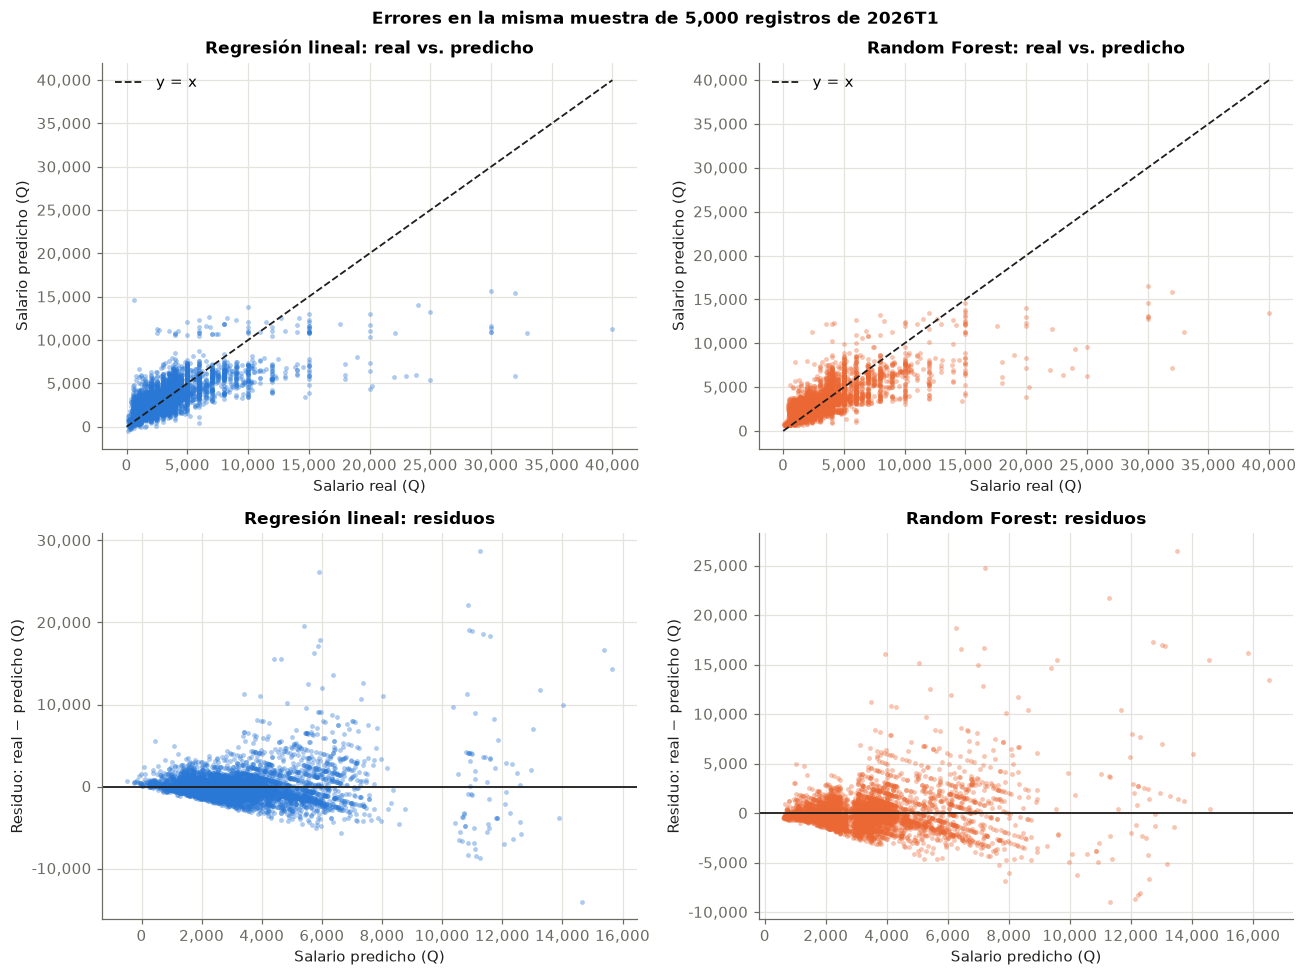

In [27]:
# Misma muestra visual para ambos modelos; todos los cálculos de error posteriores usan el total.
ids_muestra = prueba_2026.select("id_prueba").orderBy(F.rand(SEED)).limit(5000).cache()
muestra_lr = (pred_lr_2026.join(ids_muestra, "id_prueba").select("id_prueba", ETIQUETA, "prediction")
              .withColumnRenamed("prediction", "pred_lr"))
muestra_rf = (pred_rf_2026.join(ids_muestra, "id_prueba").select("id_prueba", "prediction")
              .withColumnRenamed("prediction", "pred_rf"))
muestra_error = muestra_lr.join(muestra_rf, "id_prueba").toPandas()
muestra_error["residuo_lr"] = muestra_error[ETIQUETA] - muestra_error["pred_lr"]
muestra_error["residuo_rf"] = muestra_error[ETIQUETA] - muestra_error["pred_rf"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for col_pred, col_res, titulo, color, ax_scatter, ax_res in [
    ("pred_lr", "residuo_lr", "Regresión lineal", PALETA[0], axes[0, 0], axes[1, 0]),
    ("pred_rf", "residuo_rf", "Random Forest", PALETA[1], axes[0, 1], axes[1, 1]),
]:
    limite = max(muestra_error[ETIQUETA].max(), muestra_error[col_pred].max())
    ax_scatter.scatter(muestra_error[ETIQUETA], muestra_error[col_pred], s=10, alpha=.38, color=color, linewidths=0)
    ax_scatter.plot([0, limite], [0, limite], "--", color=TINTA, lw=1.2, label="y = x")
    ax_scatter.set(xlabel="Salario real (Q)", ylabel="Salario predicho (Q)", title=f"{titulo}: real vs. predicho")
    ax_scatter.legend(frameon=False)
    ax_res.scatter(muestra_error[col_pred], muestra_error[col_res], s=10, alpha=.38, color=color, linewidths=0)
    ax_res.axhline(0, color=TINTA, lw=1.2)
    ax_res.set(xlabel="Salario predicho (Q)", ylabel="Residuo: real − predicho (Q)", title=f"{titulo}: residuos")
for ax in axes.ravel():
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
fig.suptitle(f"Errores en la misma muestra de {len(muestra_error):,} registros de 2026T1", fontweight="bold")
plt.tight_layout(); plt.show()

In [28]:
def errores_por_grupo(pred, grupo, nombre_modelo):
    d = pred.withColumn("residuo", F.col(ETIQUETA) - F.col("prediction"))
    return (d.groupBy(grupo).agg(
        F.count(F.lit(1)).alias("n"),
        F.mean(F.abs(F.col("residuo"))).alias("MAE"),
        F.mean("residuo").alias("error_medio"))
        .withColumn("modelo", F.lit(nombre_modelo)).orderBy(grupo))

for grupo in ["nivel_educativo", "dominio"]:
    tabla_grupo = errores_por_grupo(pred_lr_2026, grupo, "Regresión lineal").unionByName(
        errores_por_grupo(pred_rf_2026, grupo, "Random Forest"))
    print(f"MAE y error medio por {grupo} — todos los registros de prueba:")
    display(tabla_grupo.toPandas().round(2))

# Percentiles y sesgo a lo largo de la distribución salarial, calculados en los 13 mil+ casos de prueba.
pct_prueba = prueba_2026.selectExpr(f"percentile({ETIQUETA}, array(0.25, 0.5, 0.75, 0.95)) as p").first()["p"]
print(f"Salarios 2026T1: P25=Q{pct_prueba[0]:,.0f}, P50=Q{pct_prueba[1]:,.0f}, P75=Q{pct_prueba[2]:,.0f}, P95=Q{pct_prueba[3]:,.0f}.")

def error_por_quintil(pred, nombre):
    con_q = (pred.withColumn("quintil", F.ntile(5).over(Window.orderBy(F.col(ETIQUETA))) )
                 .withColumn("residuo", F.col(ETIQUETA) - F.col("prediction")))
    return con_q.groupBy("quintil").agg(F.count("*").alias("n"), F.mean(F.abs(F.col("residuo"))).alias("MAE"),
                                            F.mean("residuo").alias("error_medio"), F.expr(f"percentile({ETIQUETA}, 0.5)").alias("salario_mediano")) \
                .withColumn("modelo", F.lit(nombre)).orderBy("quintil")

quintiles_error = error_por_quintil(pred_lr_2026, "Regresión lineal").unionByName(error_por_quintil(pred_rf_2026, "Random Forest"))
display(quintiles_error.toPandas().round(2))

MAE y error medio por nivel_educativo — todos los registros de prueba:


,nivel_educativo,n,MAE,error_medio,modelo
0,0 - Ninguno,1016,823.51,109.34,Regresión lineal
1,1 - Preprimaria,80,735.21,88.76,Regresión lineal
2,2 - Primaria,3957,870.04,54.55,Regresión lineal
3,3 - Básico,2164,894.45,127.77,Regresión lineal
4,4 - Diversificado,4117,1109.31,103.98,Regresión lineal
5,5 - Superior,1729,2566.37,295.52,Regresión lineal
6,6 - Maestría,183,5552.87,-131.48,Regresión lineal
7,7 - Doctorado,12,12919.31,6062.73,Regresión lineal
8,0 - Ninguno,1016,687.30,-135.85,Random Forest
9,1 - Preprimaria,80,646.03,-184.43,Random Forest


MAE y error medio por dominio — todos los registros de prueba:


,dominio,n,MAE,error_medio,modelo
0,1 - Urbano Metropolitano,5632,1446.09,136.04,Regresión lineal
1,2 - Resto Urbano,4846,1189.65,134.28,Regresión lineal
2,3 - Rural Nacional,2780,913.64,65.24,Regresión lineal
3,1 - Urbano Metropolitano,5632,1338.97,220.00,Random Forest
4,2 - Resto Urbano,4846,1063.60,64.94,Random Forest
5,3 - Rural Nacional,2780,794.98,-41.87,Random Forest


Salarios 2026T1: P25=Q2,000, P50=Q3,200, P75=Q4,080, P95=Q8,000.


,quintil,n,MAE,error_medio,salario_mediano,modelo
0,1,2652,1015.24,-897.72,1000.0,Regresión lineal
1,2,2652,918.76,-499.35,2000.0,Regresión lineal
2,3,2652,841.77,-78.94,3200.0,Regresión lineal
3,4,2651,838.43,-3.47,4000.0,Regresión lineal
4,5,2651,2589.71,2082.92,6000.0,Regresión lineal
5,1,2652,918.42,-885.04,1000.0,Random Forest
6,2,2652,791.93,-527.96,2000.0,Random Forest
7,3,2652,676.50,-84.11,3200.0,Random Forest
8,4,2651,740.95,57.10,4000.0,Random Forest
9,5,2651,2493.82,1982.78,6000.0,Random Forest


### Discusión final

La tabla de 2026T1 es la comparación principal: ambos modelos se seleccionaron sin usar ese trimestre y se miden sobre la misma población elegible. Compare primero RMSE, luego MAE y R²; diferencias pequeñas deben interpretarse con cautela.

Los gráficos real–predicho muestran cercanía a la diagonal; los residuos deberían alternar alrededor de cero sin una forma clara. En particular, un **error medio positivo** en el quintil superior implica que el modelo subestima salarios altos, mientras que uno negativo implica sobreestimación. Debido a la asimetría salarial y a los valores extremos, el RMSE puede ser mucho mayor que el MAE: esto no es una contradicción, sino evidencia de que unos pocos errores muy grandes pesan más en RMSE.

El análisis por educación y dominio permite detectar si la precisión cambia entre grupos. No debe interpretarse como una evaluación de equidad causal ni como estimación oficial: se trabajó sin FACTOR de expansión, se excluyeron registros fuera de la población analítica y las variables observadas no agotan los determinantes del salario. Los modelos estiman el salario registrado en el período observado, no el salario futuro de una persona.